<a href="https://colab.research.google.com/github/armeros/DC_ML/blob/main/PySpark_ML/%20ML_with_Pyspark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import when, regexp_replace
from pyspark.ml.feature import StringIndexer, VectorAssembler, Tokenizer, StopWordsRemover, HashingTF, IDF, OneHotEncoder, Bucketizer
from pyspark.ml import Pipeline
from pyspark.sql.types import DoubleType, StructType, StructField, IntegerType, StringType, ArrayType, MapType
from pyspark.ml.classification import DecisionTreeClassifier, LogisticRegression, RandomForestClassifier, GBTClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.regression import LinearRegression

spark = SparkSession.builder.master('local[*]').appName('first_spark_application').getOrCreate()

# **Data distributed across cluster**

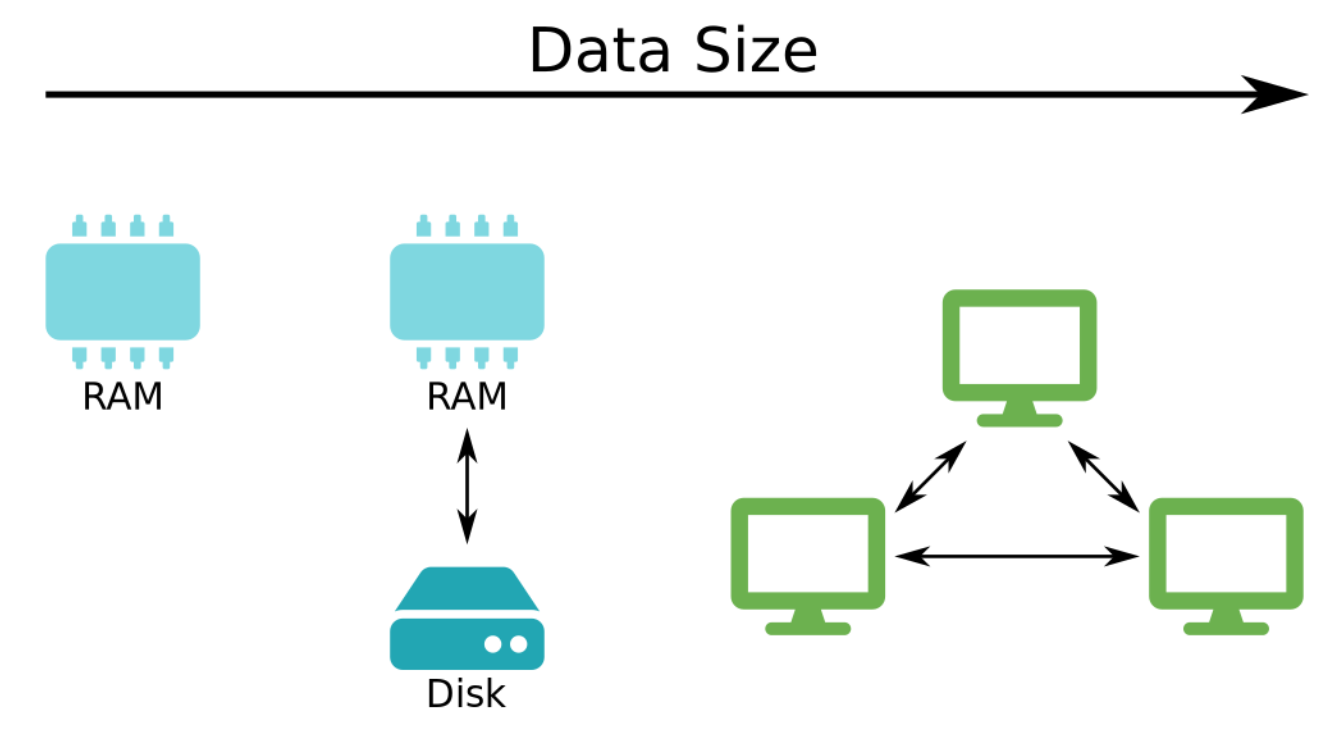

## **Characteristics of Spark**

Spark is currently the most popular technology for processing large quantities of data. Not only is it able to handle enormous data volumes, but it does so very efficiently too.

- Spark is a framework for cluster computing.
- Spark does most processing in memory.
- Spark has a high-level API, which conceals a lot of complexity.

## **Components in a Spark Cluster**

Spark is a distributed computing platform. It achieves efficiency by distributing data and computation across a cluster of computers.

A Spark cluster consists of a number of hardware and software components which work together.  It consists of

- Nodes
- Cluster manager
- Executors

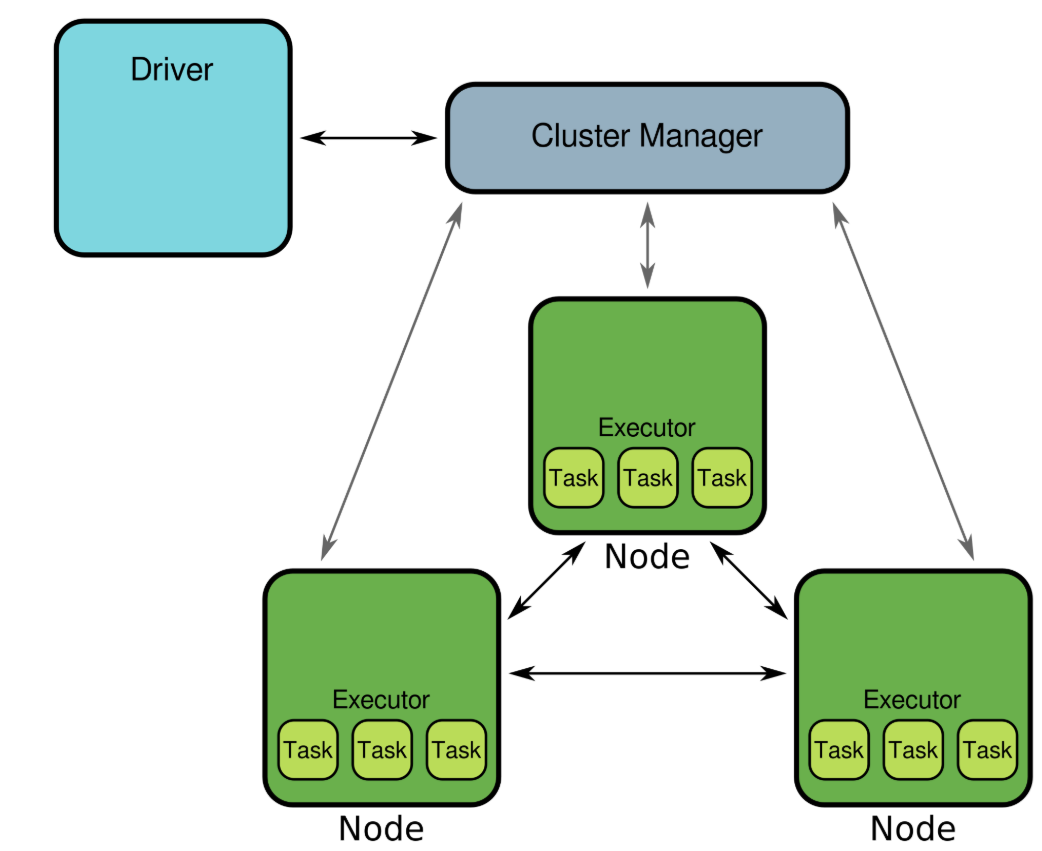


In [ ]:
import pyspark

pyspark.__version__

'4.0.2'

## **Spark URL**

- Give the network location of the cluster's master node

Example:

- `spark://13.59.151.161:7077`

## **Local Cluster**

- `local` -- only 1 core
- `local[4]` 4 cores
- `local[*]` all cores

# **Spark Session**

- In addition to the intro course, **`.master('local[*]')`** specify the location of the cluster

In [ ]:
from pyspark.sql import SparkSession
# from pyspark import SparkContext
# sc = SparkContext()
spark = SparkSession.builder.master('local[*]').appName('first_spark_application').getOrCreate()

# Terminate the cluster
# spark.stop()

## **Reading data from CSV**

**`spark.read.csv('filepath')`**

Keyword argument

- `header` -- is first row a header
- `sep` -- field separator (default is comma `', '`)
- `schema` -- explicit column data types
- `inferSchema` -- guess column types from data
- `nullValue` -- default value for missing data

In [ ]:
df = spark.read.csv("flights.csv", header=True, inferSchema=True)
df.show(5)
print(f'The dataframe has {df.count()} observations with {len(df.columns)} columns.')

+---+---+---+-------+------+---+----+------+--------+-----+
|mon|dom|dow|carrier|flight|org|mile|depart|duration|delay|
+---+---+---+-------+------+---+----+------+--------+-----+
| 11| 20|  6|     US|    19|JFK|2153|  9.48|     351|   NA|
|  0| 22|  2|     UA|  1107|ORD| 316| 16.33|      82|   30|
|  2| 20|  4|     UA|   226|SFO| 337|  6.17|      82|   -8|
|  9| 13|  1|     AA|   419|ORD|1236| 10.33|     195|   -5|
|  4|  2|  5|     AA|   325|ORD| 258|  8.92|      65|   NA|
+---+---+---+-------+------+---+----+------+--------+-----+
only showing top 5 rows
The dataframe has 50000 observations with 10 columns.


# **Check column types**

In [ ]:
df.printSchema()

root
 |-- mon: integer (nullable = true)
 |-- dom: integer (nullable = true)
 |-- dow: integer (nullable = true)
 |-- carrier: string (nullable = true)
 |-- flight: integer (nullable = true)
 |-- org: string (nullable = true)
 |-- mile: integer (nullable = true)
 |-- depart: double (nullable = true)
 |-- duration: integer (nullable = true)
 |-- delay: integer (nullable = true)



In [ ]:
df.dtypes

[('mon', 'int'),
 ('dom', 'int'),
 ('dow', 'int'),
 ('carrier', 'string'),
 ('flight', 'int'),
 ('org', 'string'),
 ('mile', 'int'),
 ('depart', 'double'),
 ('duration', 'int'),
 ('delay', 'int')]

## **Dealing with Missing Values**

- `nullValue` must be similar to the missing value in the data
   - e.g. if the missing data is `'N/A'`, you must enter `nullValue='N/A'`
   - the displayed dataframe will change `'N/A'` to `'NULL'`

In [ ]:
df = spark.read.csv('flights.csv', header=True, inferSchema=True, nullValue='NA')
df.show(5)

# How many missing values
print(f'There are {df.where("delay IS NULL").count()} missing observations in "flights.csv"')
print(f'You can get the same value using either .where() or .either(): {df.filter("delay IS NULL").count()}.')

+---+---+---+-------+------+---+----+------+--------+-----+
|mon|dom|dow|carrier|flight|org|mile|depart|duration|delay|
+---+---+---+-------+------+---+----+------+--------+-----+
| 11| 20|  6|     US|    19|JFK|2153|  9.48|     351| NULL|
|  0| 22|  2|     UA|  1107|ORD| 316| 16.33|      82|   30|
|  2| 20|  4|     UA|   226|SFO| 337|  6.17|      82|   -8|
|  9| 13|  1|     AA|   419|ORD|1236| 10.33|     195|   -5|
|  4|  2|  5|     AA|   325|ORD| 258|  8.92|      65| NULL|
+---+---+---+-------+------+---+----+------+--------+-----+
only showing top 5 rows
There are 2978 missing observations in "flights.csv"
You can get the same value using either .where() or .either(): 2978.


## **Specify column types**

In [ ]:
from pyspark.sql.types import DoubleType, StructType, StructField, IntegerType, StringType, ArrayType, MapType

schema = StructType([StructField("Month", IntegerType()),
                     StructField("Date of month", IntegerType()),
                     StructField("Date of week", IntegerType()),
                     StructField("Carrier", StringType()),
                     StructField("Flight", IntegerType()),
                     StructField("Origin", StringType()),
                     StructField("Mile", IntegerType()),
                     StructField("Departure", DoubleType()),
                     StructField("Duration", IntegerType()),
                     StructField("Delay", IntegerType())])

df = spark.read.csv('flights.csv', header=True, schema=schema, nullValue='NA')
df.show(5)
df.printSchema()

+-----+-------------+------------+-------+------+------+----+---------+--------+-----+
|Month|Date of month|Date of week|Carrier|Flight|Origin|Mile|Departure|Duration|Delay|
+-----+-------------+------------+-------+------+------+----+---------+--------+-----+
|   11|           20|           6|     US|    19|   JFK|2153|     9.48|     351| NULL|
|    0|           22|           2|     UA|  1107|   ORD| 316|    16.33|      82|   30|
|    2|           20|           4|     UA|   226|   SFO| 337|     6.17|      82|   -8|
|    9|           13|           1|     AA|   419|   ORD|1236|    10.33|     195|   -5|
|    4|            2|           5|     AA|   325|   ORD| 258|     8.92|      65| NULL|
+-----+-------------+------------+-------+------+------+----+---------+--------+-----+
only showing top 5 rows
root
 |-- Month: integer (nullable = true)
 |-- Date of month: integer (nullable = true)
 |-- Date of week: integer (nullable = true)
 |-- Carrier: string (nullable = true)
 |-- Flight: integer

### ***Exercise: Loading SMS spam data***

You've seen that it's possible to infer data types directly from the data. Sometimes it's convenient to have direct control over the column types. You do this by defining an explicit schema.

The file `sms.csv` contains a selection of SMS messages which have been classified as either `'spam'` or `'ham'`. These data have been adapted from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/228/sms+spam+collection). There are a total of 5574 SMS, of which 747 have been labelled as spam.

Notes on CSV format:

- no header record and
- fields are separated by a ***semicolon*** (this is not the default separator).

Data dictionary:

- `id` — record identifier
- `text` — content of SMS message
- `label` — spam or ham (integer; 0 = ham and 1 = spam)

### ***Instructions***

- Specify the data schema, giving columns names ("id", "text", and "label") and column types.
- Read data from a delimited file called `"sms.csv"`.
- Print the schema for the resulting DataFrame.

In [ ]:
from pyspark.sql.types import StructType, StructField, IntegerType, StringType

# Specify column names and types
schema = StructType([StructField("id", IntegerType()),
                     StructField("text", StringType()),
                     StructField("label", IntegerType())])

# Load data from a delimited file
sms = spark.read.csv('sms.csv', sep=';', header=False, schema=schema)

# Print schema of DataFrame
sms.printSchema()
sms.show(5, truncate=False)

root
 |-- id: integer (nullable = true)
 |-- text: string (nullable = true)
 |-- label: integer (nullable = true)

+---+---------------------------------------------------------------------------------------------------------------+-----+
|id |text                                                                                                           |label|
+---+---------------------------------------------------------------------------------------------------------------+-----+
|1  |Sorry, I'll call later in meeting                                                                              |0    |
|2  |Dont worry. I guess he's busy.                                                                                 |0    |
|3  |Call FREEPHONE 0800 542 0578 now!                                                                              |1    |
|4  |Win a 1000 cash prize or a prize worth 5000                                                                    |1    |
|5  |Go until jur

# **Data Preparation**

## **Dropping columns**

- `df.drop('col to drop 1', 'col to drop 2')`
- `df.select('col to have 1', col to have 2')`

## **How many missing values**

In [ ]:
df.where("delay IS NULL").count()

2978

In [ ]:
df.filter("delay IS NULL").count()

2978

## **Filtering out missing value in a particular column**

In [ ]:
df = df.filter('delay IS NOT NULL')
df.filter('delay IS NULL').count()

0

## **Dropping all missing value**

In [ ]:
df = df.dropna()
df.show(5)

+-----+-------------+------------+-------+------+------+----+---------+--------+-----+
|Month|Date of month|Date of week|Carrier|Flight|Origin|Mile|Departure|Duration|Delay|
+-----+-------------+------------+-------+------+------+----+---------+--------+-----+
|    0|           22|           2|     UA|  1107|   ORD| 316|    16.33|      82|   30|
|    2|           20|           4|     UA|   226|   SFO| 337|     6.17|      82|   -8|
|    9|           13|           1|     AA|   419|   ORD|1236|    10.33|     195|   -5|
|    5|            2|           1|     UA|   704|   SFO| 550|     7.98|     102|    2|
|    7|            2|           6|     AA|   380|   ORD| 733|    10.83|     135|   54|
+-----+-------------+------------+-------+------+------+----+---------+--------+-----+
only showing top 5 rows


## **Create new columns**

- `.withColumn('col_name', what to change)`

In [ ]:
from pyspark.sql.functions import round

df = df.withColumn('duration_round', round(df['Departure'], 0))
df.show(5)

+-----+-------------+------------+-------+------+------+----+---------+--------+-----+--------------+
|Month|Date of month|Date of week|Carrier|Flight|Origin|Mile|Departure|Duration|Delay|duration_round|
+-----+-------------+------------+-------+------+------+----+---------+--------+-----+--------------+
|    0|           22|           2|     UA|  1107|   ORD| 316|    16.33|      82|   30|          16.0|
|    2|           20|           4|     UA|   226|   SFO| 337|     6.17|      82|   -8|           6.0|
|    9|           13|           1|     AA|   419|   ORD|1236|    10.33|     195|   -5|          10.0|
|    5|            2|           1|     UA|   704|   SFO| 550|     7.98|     102|    2|           8.0|
|    7|            2|           6|     AA|   380|   ORD| 733|    10.83|     135|   54|          11.0|
+-----+-------------+------------+-------+------+------+----+---------+--------+-----+--------------+
only showing top 5 rows


## **Indexing categorical data**

In [ ]:
from pyspark.ml.feature import StringIndexer

indexer = StringIndexer(inputCol="Carrier", outputCol="Carrier_index")
indexer = indexer.fit(df)
df = indexer.transform(df)
df.select('Carrier', 'Carrier_index').show(5)

+-------+-------------+
|Carrier|Carrier_index|
+-------+-------------+
|     UA|          0.0|
|     UA|          0.0|
|     AA|          1.0|
|     UA|          0.0|
|     AA|          1.0|
+-------+-------------+
only showing top 5 rows


In [ ]:
df = StringIndexer(inputCol="Origin", outputCol="Origin_index").fit(df).transform(df)
df.select('Origin', 'Origin_index').show(5)

+------+------------+
|Origin|Origin_index|
+------+------------+
|   ORD|         0.0|
|   SFO|         1.0|
|   ORD|         0.0|
|   SFO|         1.0|
|   ORD|         0.0|
+------+------------+
only showing top 5 rows


We can index this ourself with **`when`** for binary index

In [ ]:
from pyspark.sql.functions import when

df = df.withColumn("label", when(df["delay"] > 15, 1).otherwise(0))
df.show(5)

+-----+-------------+------------+-------+------+------+----+---------+--------+-----+-------------+------------+-----+
|Month|Date of month|Date of week|Carrier|Flight|Origin|Mile|Departure|Duration|Delay|Carrier_index|Origin_index|label|
+-----+-------------+------------+-------+------+------+----+---------+--------+-----+-------------+------------+-----+
|    0|           22|           2|     UA|  1107|   ORD| 316|    16.33|      82|   30|          0.0|         0.0|    1|
|    2|           20|           4|     UA|   226|   SFO| 337|     6.17|      82|   -8|          0.0|         1.0|    0|
|    9|           13|           1|     AA|   419|   ORD|1236|    10.33|     195|   -5|          1.0|         0.0|    0|
|    5|            2|           1|     UA|   704|   SFO| 550|     7.98|     102|    2|          0.0|         1.0|    0|
|    7|            2|           6|     AA|   380|   ORD| 733|    10.83|     135|   54|          1.0|         0.0|    1|
+-----+-------------+------------+------

## **Assembling columns**

In [ ]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(inputCols=["Month", "Date of month", "Date of week", "Carrier_index", "Origin_index", "Mile", "Departure", "Duration"], outputCol='features')
df = assembler.transform(df)
df[["Carrier_index", "Origin_index", "Duration", "features"]].show(5, truncate=False)

+-------------+------------+--------+-----------------------------------------+
|Carrier_index|Origin_index|Duration|features                                 |
+-------------+------------+--------+-----------------------------------------+
|0.0          |0.0         |82      |[0.0,22.0,2.0,0.0,0.0,316.0,16.33,82.0]  |
|0.0          |1.0         |82      |[2.0,20.0,4.0,0.0,1.0,337.0,6.17,82.0]   |
|1.0          |0.0         |195     |[9.0,13.0,1.0,1.0,0.0,1236.0,10.33,195.0]|
|0.0          |1.0         |102     |[5.0,2.0,1.0,0.0,1.0,550.0,7.98,102.0]   |
|1.0          |0.0         |135     |[7.0,2.0,6.0,1.0,0.0,733.0,10.83,135.0]  |
+-------------+------------+--------+-----------------------------------------+
only showing top 5 rows


### ***Exercise: Removing columns and rows***

You previously loaded airline flight data from a CSV file. You're going to develop a model which will *predict whether or not a given flight will be delayed*.

In this exercise you need to trim those data down by:

1. removing an uninformative column and
2. removing rows which do not have information about whether or not a flight was delayed.

The data are available as `flights`.

#### ***Instructions***

- Remove the `flight` column.
- Find out how many records have missing values in the `delay` column.
- Remove records with missing values in the `delay` column.
- Remove records with missing values in any column and get the number of remaining rows.

In [ ]:
flights = spark.read.csv("flights.csv", header=True, inferSchema=True, nullValue="NA")

# Remove the 'flight' column
flights_drop_column = flights.drop('flight')

# Number of records with missing 'delay' values
flights_drop_column.filter('delay IS NULL').count()

# Remove records with missing 'delay' values
flights_valid_delay = flights_drop_column.filter('delay IS NOT NULL')

# Remove records with missing values in any column and get the number of remaining rows
flights_none_missing = flights_valid_delay.dropna()
print(flights_none_missing.count())

47022


### ***Exercise: Column manipulation***

The Federal Aviation Administration (FAA) considers a flight to be "delayed" when it arrives 15 minutes or more after its scheduled time.

The next step of preparing the flight data has two parts:

1. convert the units of distance, replacing the `mile` column with a `km` column; and
2. create a Boolean column indicating whether or not a flight was delayed.


#### ***Instructions***

- Import a function which will allow you to round a number to a specific number of decimal places.
- Derive a new `km` column from the `mile` column, rounding to zero decimal places. One mile is 1.60934 km.
- Remove the `mile` column.
- Create a `label` column with a value of `1` indicating the delay was 15 minutes or more and `0` otherwise. Think carefully about the logical condition.

In [ ]:
# Import the required function
from pyspark.sql.functions import round

flights = flights_none_missing

# Convert 'mile' to 'km' and drop 'mile' column (1 mile is equivalent to 1.60934 km)
flights_km = flights.withColumn('km', round(flights['mile'] * 1.60934, 0)) \
                    .drop('mile')

# Create 'label' column indicating whether flight delayed (1) or not (0)
flights_km = flights_km.withColumn('label', (flights['delay']>=15).cast('integer'))

# Check first five records
flights_km.show(5)

+---+---+---+-------+---+------+--------+-----+------+-----+
|mon|dom|dow|carrier|org|depart|duration|delay|    km|label|
+---+---+---+-------+---+------+--------+-----+------+-----+
|  0| 22|  2|     UA|ORD| 16.33|      82|   30| 509.0|    1|
|  2| 20|  4|     UA|SFO|  6.17|      82|   -8| 542.0|    0|
|  9| 13|  1|     AA|ORD| 10.33|     195|   -5|1989.0|    0|
|  5|  2|  1|     UA|SFO|  7.98|     102|    2| 885.0|    0|
|  7|  2|  6|     AA|ORD| 10.83|     135|   54|1180.0|    1|
+---+---+---+-------+---+------+--------+-----+------+-----+
only showing top 5 rows


### ***Exercise: Categorical columns***

In the flights data there are two columns, `carrier` and `org`, which hold categorical data. You need to transform those columns into indexed numerical values.

#### ***Instructions***

- Import the appropriate class and create an indexer object to transform the `carrier` column from a string to an numeric index.
- Prepare the indexer object on the flight data.
- Use the prepared indexer to create the numeric index column.
- Repeat the process for the `org` column.

In [ ]:
flights = flights_km

from pyspark.ml.feature import StringIndexer

# Create an indexer
indexer = StringIndexer(inputCol='carrier', outputCol='carrier_idx')

# Indexer identifies categories in the data
indexer_model = indexer.fit(flights)

# Indexer creates a new column with numeric index values
flights_indexed = indexer_model.transform(flights)

# Repeat the process for the other categorical feature
flights_indexed = StringIndexer(inputCol='org', outputCol='org_idx').fit(flights_indexed).transform(flights_indexed)
flights_indexed.show(5)

+---+---+---+-------+---+------+--------+-----+------+-----+-----------+-------+
|mon|dom|dow|carrier|org|depart|duration|delay|    km|label|carrier_idx|org_idx|
+---+---+---+-------+---+------+--------+-----+------+-----+-----------+-------+
|  0| 22|  2|     UA|ORD| 16.33|      82|   30| 509.0|    1|        0.0|    0.0|
|  2| 20|  4|     UA|SFO|  6.17|      82|   -8| 542.0|    0|        0.0|    1.0|
|  9| 13|  1|     AA|ORD| 10.33|     195|   -5|1989.0|    0|        1.0|    0.0|
|  5|  2|  1|     UA|SFO|  7.98|     102|    2| 885.0|    0|        0.0|    1.0|
|  7|  2|  6|     AA|ORD| 10.83|     135|   54|1180.0|    1|        1.0|    0.0|
+---+---+---+-------+---+------+--------+-----+------+-----+-----------+-------+
only showing top 5 rows


### ***Exercise: Assembling columns***

The final stage of data preparation is to consolidate all of the predictor columns into a single column.

An updated version of the `flights` data, which takes into account all of the changes from the previous few exercises, has the following predictor columns:

- `mon`, `dom` and `dow`
- `carrier_idx` (indexed value from `carrier`)
- `org_idx` (indexed value from `org`)
- `km`
- `depart`
- `duration`

Note: The `truncate=False` argument to the **`show()`** method prevents data being truncated in the output.

#### ***Instructions***

- Import the class which will assemble the predictors.
- Create an assembler object that will allow you to merge the predictors columns into a single column.
- Use the assembler to generate a new consolidated column.

In [ ]:
flights = flights_indexed

# Import the necessary class
from pyspark.ml.feature import VectorAssembler

# Create an assembler object
assembler = VectorAssembler(inputCols=['mon', 'dom', 'dow', 'carrier_idx', 'org_idx', 'km', 'depart', 'duration'], outputCol='features')

# Consolidate predictor columns
flights_assembled = assembler.transform(flights)

# Check the resulting column
flights_assembled.select('features', 'delay').show(5, truncate=False)

+-----------------------------------------+-----+
|features                                 |delay|
+-----------------------------------------+-----+
|[0.0,22.0,2.0,0.0,0.0,509.0,16.33,82.0]  |30   |
|[2.0,20.0,4.0,0.0,1.0,542.0,6.17,82.0]   |-8   |
|[9.0,13.0,1.0,1.0,0.0,1989.0,10.33,195.0]|-5   |
|[5.0,2.0,1.0,0.0,1.0,885.0,7.98,102.0]   |2    |
|[7.0,2.0,6.0,1.0,0.0,1180.0,10.83,135.0] |54   |
+-----------------------------------------+-----+
only showing top 5 rows


# **Decision Tree**

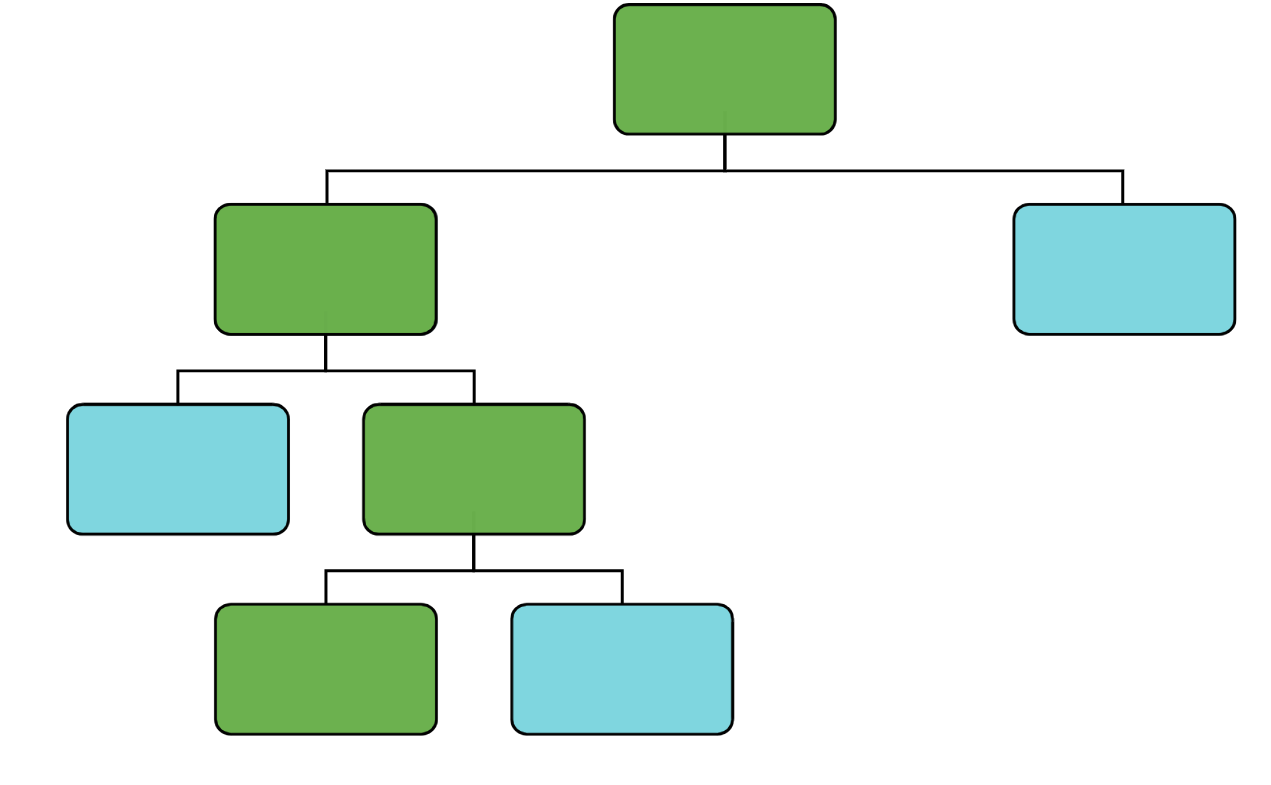

In [ ]:
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.classification import DecisionTreeClassifier

df = spark.read.csv("flights.csv", header=True, inferSchema=True, nullValue="NA")
df = df.dropna()
df = df.withColumn("kilometre", df["mile"]*1.609344)
df = df.withColumn("label", (df['delay']>=15).cast('integer'))
df = StringIndexer(inputCol="carrier",  outputCol="carrier_index").fit(df).transform(df)
df = StringIndexer(inputCol="org", outputCol="org_index").fit(df).transform(df)
df = VectorAssembler(inputCols=["mon", "dom", "dow", "carrier_index", "org_index", "kilometre", "depart", "duration"], outputCol='features').transform(df)
df.show(5, truncate=False)

+---+---+---+-------+------+---+----+------+--------+-----+------------------+-----+-------------+---------+----------------------------------------------------+
|mon|dom|dow|carrier|flight|org|mile|depart|duration|delay|kilometre         |label|carrier_index|org_index|features                                            |
+---+---+---+-------+------+---+----+------+--------+-----+------------------+-----+-------------+---------+----------------------------------------------------+
|0  |22 |2  |UA     |1107  |ORD|316 |16.33 |82      |30   |508.55270400000006|1    |0.0          |0.0      |[0.0,22.0,2.0,0.0,0.0,508.55270400000006,16.33,82.0]|
|2  |20 |4  |UA     |226   |SFO|337 |6.17  |82      |-8   |542.348928        |0    |0.0          |1.0      |[2.0,20.0,4.0,0.0,1.0,542.348928,6.17,82.0]         |
|9  |13 |1  |AA     |419   |ORD|1236|10.33 |195     |-5   |1989.149184       |0    |1.0          |0.0      |[9.0,13.0,1.0,1.0,0.0,1989.149184,10.33,195.0]      |
|5  |2  |1  |UA     |704   |

## **`Train_test_split` on PySpark**

In [ ]:
df_train, df_test = df.randomSplit([0.8, 0.2], seed=23)
df_train.count(), df_test.count()

(37636, 9386)

## **Build a Decision Tree Model**

In [ ]:
from pyspark.ml.classification import DecisionTreeClassifier

tree = DecisionTreeClassifier()
tree_model = tree.fit(df_train)
prediction = tree_model.transform(df_test)
prediction['label', 'probability', 'prediction'].show(30, truncate=False)

+-----+----------------------------------------+----------+
|label|probability                             |prediction|
+-----+----------------------------------------+----------+
|0    |[0.38511371467953137,0.6148862853204686]|1.0       |
|0    |[0.38511371467953137,0.6148862853204686]|1.0       |
|0    |[0.38511371467953137,0.6148862853204686]|1.0       |
|1    |[0.31321649756226116,0.6867835024377388]|1.0       |
|1    |[0.38511371467953137,0.6148862853204686]|1.0       |
|1    |[0.31321649756226116,0.6867835024377388]|1.0       |
|1    |[0.31321649756226116,0.6867835024377388]|1.0       |
|1    |[0.31321649756226116,0.6867835024377388]|1.0       |
|1    |[0.38511371467953137,0.6148862853204686]|1.0       |
|1    |[0.31321649756226116,0.6867835024377388]|1.0       |
|1    |[0.31321649756226116,0.6867835024377388]|1.0       |
|1    |[0.31321649756226116,0.6867835024377388]|1.0       |
|0    |[0.752442996742671,0.247557003257329]   |0.0       |
|1    |[0.31321649756226116,0.6867835024

## **Confusion Matrix**

In [ ]:
prediction.groupBy('label', 'prediction').count().show()

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    1|       0.0| 1274|
|    0|       0.0| 2498|
|    1|       1.0| 3481|
|    0|       1.0| 2133|
+-----+----------+-----+





```
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    1|       0.0| 1274| <--- False Negative (FN)
|    0|       0.0| 2498| <--- True Negative (TN)
|    1|       1.0| 3481| <--- True Positive (TP)
|    0|       1.0| 2133| <--- False Positive (FP)
+-----+----------+-----+
```

Accuracy = $\dfrac{TP + TN}{TP + TN + FP + FN} = \dfrac{2498 + 3481}{2498 + 3481 + 1274 + 2133} = 0.64$

This has 64% accuracy



# **Logistic Regression**

In [ ]:
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.classification import LogisticRegression

# Prepare data
df = spark.read.csv("flights.csv", header=True, inferSchema=True, nullValue="NA")
df = df.dropna()
df = df.withColumn("kilometre", df["mile"]*1.609344)
df = df.withColumn("label", (df['delay']>=15).cast('integer'))
df = StringIndexer(inputCol="carrier",  outputCol="carrier_index").fit(df).transform(df)
df = StringIndexer(inputCol="org", outputCol="org_index").fit(df).transform(df)
df = VectorAssembler(inputCols=["mon", "dom", "dow", "carrier_index", "org_index", "kilometre", "depart", "duration"], outputCol='features').transform(df)
df.show(5, truncate=False)

# Split data
df_train, df_test = df.randomSplit([0.8, 0.2])

# Create a Logistic Regression Classifier
logit = LogisticRegression(labelCol='label')
logit = logit.fit(df_train)
predict = logit.transform(df_test)
predict['label', 'probability', 'prediction'].show(5)


+---+---+---+-------+------+---+----+------+--------+-----+------------------+-----+-------------+---------+----------------------------------------------------+
|mon|dom|dow|carrier|flight|org|mile|depart|duration|delay|kilometre         |label|carrier_index|org_index|features                                            |
+---+---+---+-------+------+---+----+------+--------+-----+------------------+-----+-------------+---------+----------------------------------------------------+
|0  |22 |2  |UA     |1107  |ORD|316 |16.33 |82      |30   |508.55270400000006|1    |0.0          |0.0      |[0.0,22.0,2.0,0.0,0.0,508.55270400000006,16.33,82.0]|
|2  |20 |4  |UA     |226   |SFO|337 |6.17  |82      |-8   |542.348928        |0    |0.0          |1.0      |[2.0,20.0,4.0,0.0,1.0,542.348928,6.17,82.0]         |
|9  |13 |1  |AA     |419   |ORD|1236|10.33 |195     |-5   |1989.149184       |0    |1.0          |0.0      |[9.0,13.0,1.0,1.0,0.0,1989.149184,10.33,195.0]      |
|5  |2  |1  |UA     |704   |

## **Confusion Matrix**

In [ ]:
predict.groupBy('label', 'prediction').count().show()

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    1|       0.0| 1668|
|    0|       0.0| 2544|
|    1|       1.0| 3131|
|    0|       1.0| 2055|
+-----+----------+-----+



## **Accuracy**

In [ ]:
TN = predict.filter('prediction = 0 AND label = prediction').count()
TP = predict.filter('prediction = 1 AND label = prediction').count()
FN = predict.filter('prediction = 0 AND label != prediction').count()
FP = predict.filter('prediction = 1 AND label != prediction').count()

# Accuracy measures the proportion of correct predictions
accuracy = (TP+TN)/(TP+TN+FP+FN)
print(accuracy)

0.6038518833794424


## **Precision**

- proportion of ***positive <u>predictions</u>*** that are correct

In [ ]:
TP/(TP + FP)

0.6037408407250289

## **Recall**

- proportion of ***positive <u>labels</u>*** that are correctly

In [ ]:
TP/(TP + FN)

0.6524275890810586

## **Weighted Metrics**

In [ ]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator

evaluator = MulticlassClassificationEvaluator()
evaluator.evaluate(predict, {evaluator.metricName: 'weightedPrecision'})

0.6038620860164932

In [ ]:
evaluator.evaluate(predict, {evaluator.metricName: 'weightedRecall'})

0.6038518833794424

In [ ]:
evaluator.evaluate(predict, {evaluator.metricName: 'accuracy'})

0.6038518833794424

In [ ]:
evaluator.evaluate(predict, {evaluator.metricName: 'f1'})


0.6028289828783722

## **ROC and AUC**

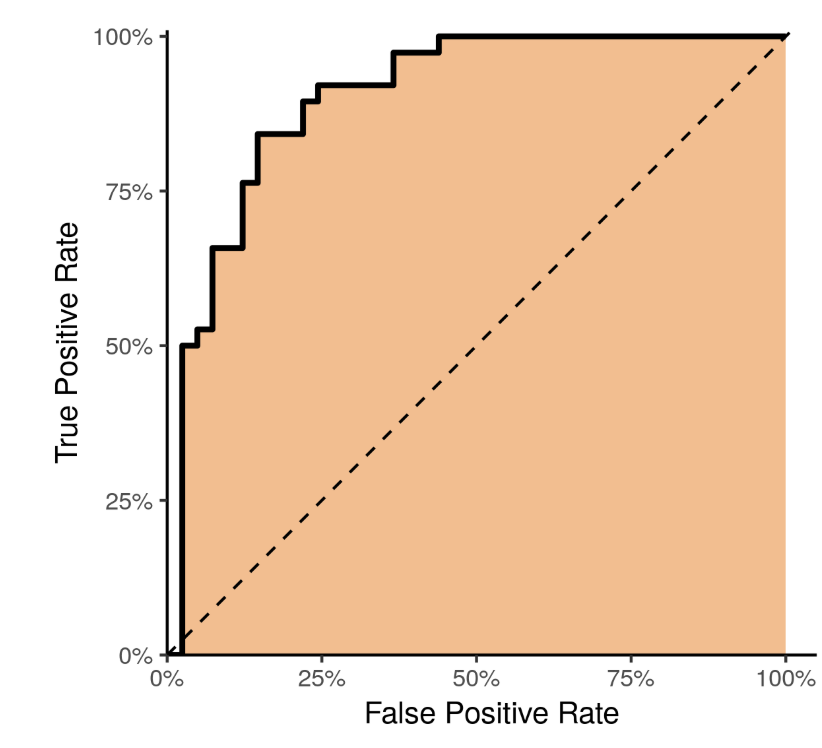

- Threshold = 0 (top right) Everything is positively predicted
- Threshold = 1 (bottom left) Everything is negatively predicted

AUC

- ideally AUC = 1
- Worst AUC = 0.5

In [ ]:
# Find AUC
binary_evaluator = BinaryClassificationEvaluator()
auc = binary_evaluator.evaluate(predict, {binary_evaluator.metricName: "areaUnderROC"})
print(auc)

0.6441810986479265


# **Turning Text into Tables**

In [ ]:
from pyspark.sql.functions import regexp_replace
from pyspark.ml.feature import Tokenizer, StopWordsRemover, HashingTF, IDF
from pyspark.sql.types import StructType, StructField, IntegerType, StringType

# Specify column names and types
schema = StructType([StructField("id", IntegerType()),
                     StructField("text", StringType()),
                     StructField("label", IntegerType())])

# Load data from a delimited file
sms = spark.read.csv('sms.csv', sep=';', header=False, schema=schema)
sms.show(5, truncate=False)


+---+---------------------------------------------------------------------------------------------------------------+-----+
|id |text                                                                                                           |label|
+---+---------------------------------------------------------------------------------------------------------------+-----+
|1  |Sorry, I'll call later in meeting                                                                              |0    |
|2  |Dont worry. I guess he's busy.                                                                                 |0    |
|3  |Call FREEPHONE 0800 542 0578 now!                                                                              |1    |
|4  |Win a 1000 cash prize or a prize worth 5000                                                                    |1    |
|5  |Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...|0    |
+---+---

## **Removing punctuation**

In [ ]:
# Removing punctuation
REGEX = '[_():;,.!?\\- 0-9]'
sms = sms.withColumn('text', regexp_replace(sms['text'], REGEX, ' '))
sms.show(5, truncate=False)

+---+---------------------------------------------------------------------------------------------------------------+-----+
|id |text                                                                                                           |label|
+---+---------------------------------------------------------------------------------------------------------------+-----+
|1  |Sorry  I'll call later in meeting                                                                              |0    |
|2  |Dont worry  I guess he's busy                                                                                  |0    |
|3  |Call FREEPHONE               now                                                                               |1    |
|4  |Win a      cash prize or a prize worth                                                                         |1    |
|5  |Go until jurong point  crazy   Available only in bugis n great world la e buffet    Cine there got amore wat   |0    |
+---+---

In [ ]:
# Replace more than 2 spaces
sms = sms.withColumn('text', regexp_replace(sms['text'], r" {2,}", ' '))
sms.show(5, truncate=False)

+---+-------------------------------------------------------------------------------------------------------+-----+
|id |text                                                                                                   |label|
+---+-------------------------------------------------------------------------------------------------------+-----+
|1  |Sorry I'll call later in meeting                                                                       |0    |
|2  |Dont worry I guess he's busy                                                                           |0    |
|3  |Call FREEPHONE now                                                                                     |1    |
|4  |Win a cash prize or a prize worth                                                                      |1    |
|5  |Go until jurong point crazy Available only in bugis n great world la e buffet Cine there got amore wat |0    |
+---+-------------------------------------------------------------------

## **Text to Tokens**

- Create a column consisting **`list`** of words.

In [ ]:
from pyspark.ml.feature import Tokenizer

sms = Tokenizer(inputCol='text', outputCol='tokens').transform(sms)
sms.show(5, truncate=False)

+---+-------------------------------------------------------------------------------------------------------+-----+---------------------------------------------------------------------------------------------------------------------------+
|id |text                                                                                                   |label|tokens                                                                                                                     |
+---+-------------------------------------------------------------------------------------------------------+-----+---------------------------------------------------------------------------------------------------------------------------+
|1  |Sorry I'll call later in meeting                                                                       |0    |[sorry, i'll, call, later, in, meeting]                                                                                    |
|2  |Dont worry I guess he's busy       

## **Stop Words Remover**

In [ ]:
from pyspark.ml.feature import StopWordsRemover

stopwords = StopWordsRemover()
#stopwords.getStopWords()

## **Removing Stop Words**

In [ ]:
stopwords = stopwords.setInputCol('tokens').setOutputCol('words')
sms = stopwords.transform(sms)
sms['tokens', 'words'].show(5, truncate=False)

+---------------------------------------------------------------------------------------------------------------------------+---------------------------------------------------------------------------------------------------+
|tokens                                                                                                                     |words                                                                                              |
+---------------------------------------------------------------------------------------------------------------------------+---------------------------------------------------------------------------------------------------+
|[sorry, i'll, call, later, in, meeting]                                                                                    |[sorry, call, later, meeting]                                                                      |
|[dont, worry, i, guess, he's, busy]                                                            

## **Feature Hashing**

- convert words into numbers


In [ ]:
from pyspark.ml.feature import HashingTF

hasher = HashingTF(inputCol='words', outputCol='hash', numFeatures=1024)
sms = hasher.transform(sms)


In [ ]:
sms['words', 'hash'].show(4, truncate=False)

+--------------------------------+------------------------------------------+
|words                           |hash                                      |
+--------------------------------+------------------------------------------+
|[sorry, call, later, meeting]   |(1024,[138,384,577,996],[1.0,1.0,1.0,1.0])|
|[dont, worry, guess, busy]      |(1024,[215,233,276,329],[1.0,1.0,1.0,1.0])|
|[call, freephone]               |(1024,[133,138],[1.0,1.0])                |
|[win, cash, prize, prize, worth]|(1024,[31,47,62,389],[1.0,1.0,1.0,2.0])   |
+--------------------------------+------------------------------------------+
only showing top 4 rows


## **Dealing with common words**

In [ ]:
from pyspark.ml.feature import IDF

sms = IDF(inputCol='hash', outputCol='features').fit(sms).transform(sms)
sms.select('features').show(5)

+--------------------+
|            features|
+--------------------+
|(1024,[138,384,57...|
|(1024,[215,233,27...|
|(1024,[133,138],[...|
|(1024,[31,47,62,3...|
|(1024,[12,171,191...|
+--------------------+
only showing top 5 rows


### ***Exercise: Training a spam classifier***

In [ ]:
# Split the data into training and testing sets
sms_train, sms_test = sms.randomSplit([0.8, 0.2], seed=13)

# Fit a Logistic Regression model to the training data
logistic = LogisticRegression(regParam=0.2).fit(sms_train)

# Make predictions on the testing data
prediction = logistic.transform(sms_test)

# Create a confusion matrix, comparing predictions to known labels
prediction.groupBy('label', 'prediction').count().show()

TP = prediction.where("label = 1 AND prediction = 1").count()
TN = prediction.where("label = 0 AND prediction = 0").count()
FP = prediction.where("label = 0 AND prediction = 1").count()
FN = prediction.where("label = 1 AND prediction = 0").count()
print(f"The accuracy is {(TP+TN)/(TP+TN+FP+FN)*100:.2f}%")

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    1|       0.0|   41|
|    0|       0.0|  948|
|    1|       1.0|  105|
|    0|       1.0|    2|
+-----+----------+-----+

The accuracy is 96.08%


# **One Hot Encoder**


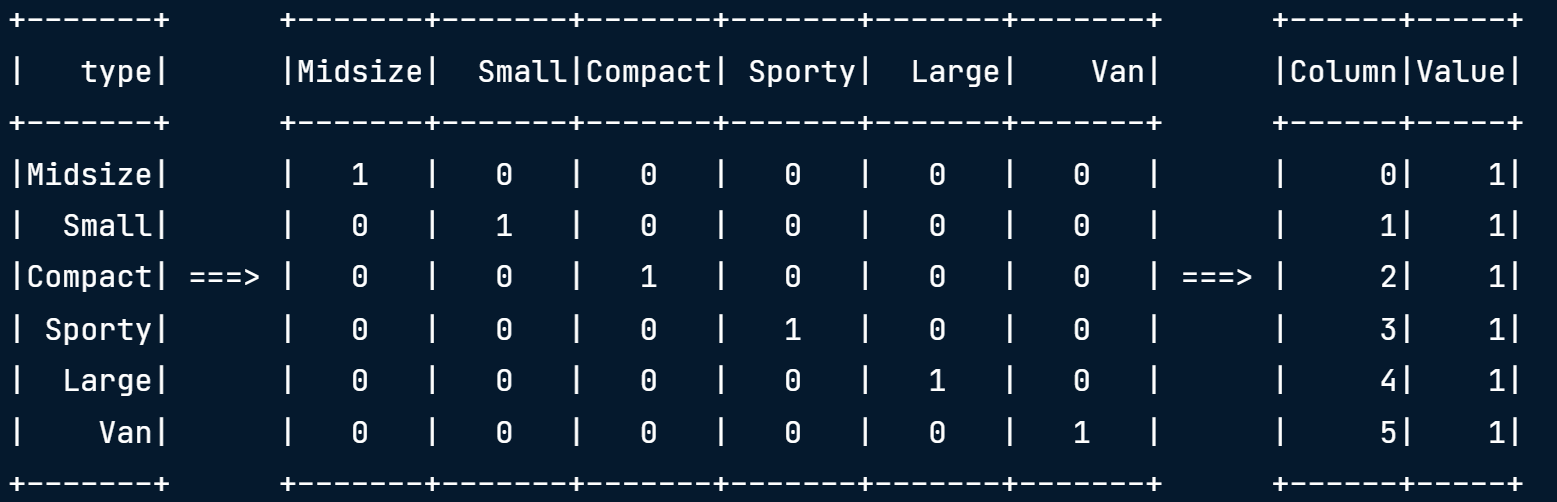



## **One Hot Encode: Redundant Column**

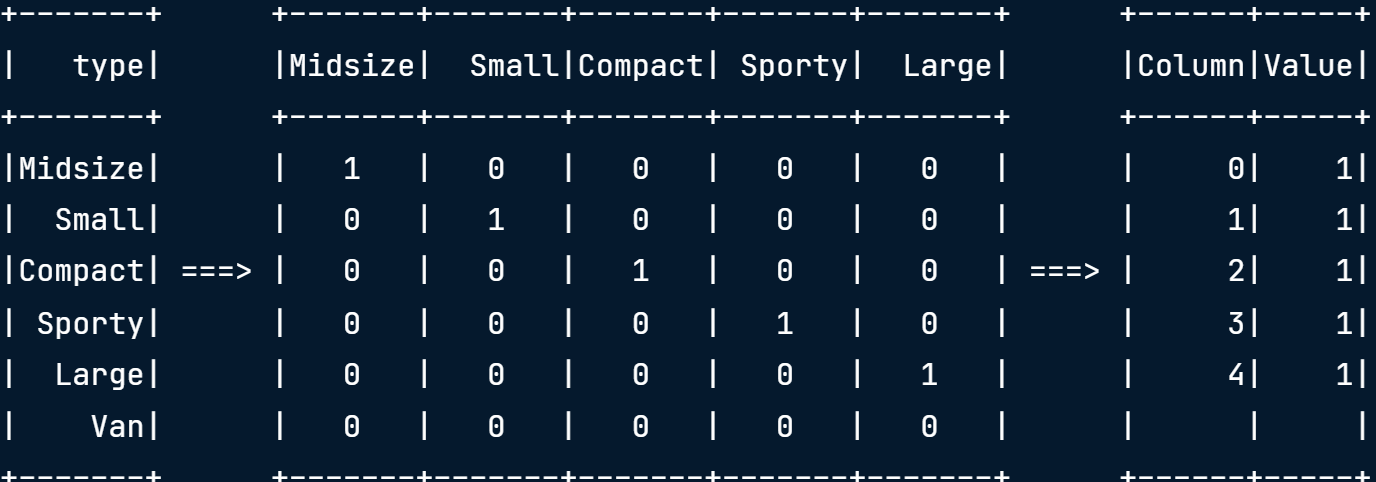

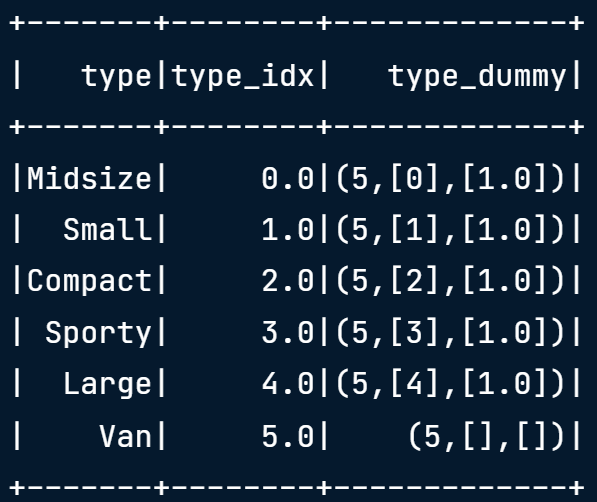

In [ ]:
from pyspark.ml.feature import OneHotEncoder

df = spark.read.csv("flights.csv", header=True, inferSchema=True, nullValue="NA")
df = df.dropna()
df = df.withColumn("kilometre", df["mile"]*1.609344)
df = df.withColumn("label", (df['delay']>=15).cast('integer'))
df = StringIndexer(inputCol="carrier",  outputCol="carrier_index").fit(df).transform(df)
df = StringIndexer(inputCol="org", outputCol="org_index").fit(df).transform(df)
df = VectorAssembler(inputCols=["mon", "dom", "dow", "carrier_index", "org_index", "kilometre", "depart", "duration"], outputCol='features').transform(df)

# One Hot
onehot = OneHotEncoder(inputCols=["carrier_index", "org_index"], outputCols=['carrier_dummy', 'org_dummy'])
onehot = onehot.fit(df)
df = onehot.transform(df)

# when show df, it shows only in terms of sparse values to conserve memory
df['org', 'org_index', 'org_dummy'].distinct().sort('org_index').show(truncate=False)

# How many category levels
onehot.categorySizes


+---+---------+-------------+
|org|org_index|org_dummy    |
+---+---------+-------------+
|ORD|0.0      |(7,[0],[1.0])|
|SFO|1.0      |(7,[1],[1.0])|
|JFK|2.0      |(7,[2],[1.0])|
|LGA|3.0      |(7,[3],[1.0])|
|SMF|4.0      |(7,[4],[1.0])|
|SJC|5.0      |(7,[5],[1.0])|
|TUS|6.0      |(7,[6],[1.0])|
|OGG|7.0      |(7,[],[])    |
+---+---------+-------------+



[9, 8]

# **Regression**

## **Loss Function**

$$MSE = \frac{1}{N}\sum_{i=1}^N(y_i - \hat{y}_i)^2$$

- $y_i --$ observed values
- $\hat{y}_i --$ model predicted values

In [ ]:
# Prepare data putting dummies into VectorAssembler

df = spark.read.csv("flights.csv", header=True, inferSchema=True, nullValue="NA")
df = df.dropna()
df = df.withColumn("kilometre", df["mile"]*1.609344)
df = df.withColumn("label", (df['delay']>=15).cast('integer'))
df = StringIndexer(inputCol="carrier",  outputCol="carrier_index").fit(df).transform(df)
df = StringIndexer(inputCol="org", outputCol="org_index").fit(df).transform(df)
onehot = OneHotEncoder(inputCols=["carrier_index", "org_index"], outputCols=['carrier_dummy', 'org_dummy'])
df = onehot.fit(df).transform(df)
df = VectorAssembler(inputCols=["mon", "dom", "dow", "carrier_dummy", "org_dummy", "kilometre", "depart"], outputCol='features').transform(df)
df.show(5, truncate=False)

+---+---+---+-------+------+---+----+------+--------+-----+------------------+-----+-------------+---------+-------------+-------------+----------------------------------------------------------------------+
|mon|dom|dow|carrier|flight|org|mile|depart|duration|delay|kilometre         |label|carrier_index|org_index|carrier_dummy|org_dummy    |features                                                              |
+---+---+---+-------+------+---+----+------+--------+-----+------------------+-----+-------------+---------+-------------+-------------+----------------------------------------------------------------------+
|0  |22 |2  |UA     |1107  |ORD|316 |16.33 |82      |30   |508.55270400000006|1    |0.0          |0.0      |(8,[0],[1.0])|(7,[0],[1.0])|(20,[1,2,3,11,18,19],[22.0,2.0,1.0,1.0,508.55270400000006,16.33])     |
|2  |20 |4  |UA     |226   |SFO|337 |6.17  |82      |-8   |542.348928        |0    |0.0          |1.0      |(8,[0],[1.0])|(7,[1],[1.0])|(20,[0,1,2,3,12,18,19],[2.0,20.0

## **Build regression model**

In [ ]:
from pyspark.ml.regression import LinearRegression

df_train, df_test = df.randomSplit([0.8, 0.2], seed=42)
reg = LinearRegression(labelCol='duration')
reg = reg.fit(df_train)
pred = reg.transform(df_test)

In [ ]:
pred['duration', 'prediction'].show(5)

+--------+------------------+
|duration|        prediction|
+--------+------------------+
|     560|  552.047400756131|
|     310|305.71711064151987|
|     165|149.11002743032583|
|     120| 128.9781744542912|
|     240|226.94660954814987|
+--------+------------------+
only showing top 5 rows


## **RMSE**

- The smaller the better

In [ ]:
from pyspark.ml.evaluation import RegressionEvaluator

RegressionEvaluator(labelCol='duration').evaluate(pred)

10.7099347176535

## **Examine Intercept**

In [ ]:
reg.intercept

17.092356012727617

## **Examine Coefficients**

In [ ]:
reg.coefficients

DenseVector([0.094, 0.0112, -0.0405, -11.2187, -13.2351, -9.5561, -12.2245, -18.8346, -9.2712, -14.8187, -2.8383, 35.526, 26.9545, 62.734, 54.7751, 23.2526, 26.0828, 25.6326, 0.0749, 0.1514])

In [ ]:
# Linear regression
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.sql.functions import when
from pyspark.ml.feature import StringIndexer, VectorAssembler, OneHotEncoder

df = spark.read.csv("flights.csv", header=True, inferSchema=True, nullValue="NA")
df = df.withColumn("km", df["mile"]*1.609344).drop("mile")

# One variable regression: Y = duration, X = km
df = VectorAssembler(inputCols=["km"], outputCol='features').transform(df)
regression = LinearRegression(labelCol="duration")
df_train, df_test = df.randomSplit([0.8, 0.2], seed=42)
regression = regression.fit(df_train)
predictions = regression.transform(df_test)
print("RMSE = ", RegressionEvaluator(labelCol="duration").evaluate(predictions))
predictions[["duration", "prediction"]].show(5)



RMSE =  17.098406021968962
+--------+------------------+
|duration|        prediction|
+--------+------------------+
|     560| 560.7390896231818|
|     310| 346.9189834661732|
|      90|  85.0289046671506|
|     130|133.58566184224821|
|     251|245.42440831822486|
+--------+------------------+
only showing top 5 rows



### ***Exercise: Interpreting the coefficients***

$$\text{duration} = \alpha + \beta_0 \cdot \text{mon} + \beta_1\cdot\text{dom} + \ldots + \beta_{18}\cdot \text{kilometre} + \beta_{19}\cdot \text{depart} $$

-  $\beta_{19}$ is a rate at which duration in minutes increases on average as a function of distance

ใช้เวลา 0.07 นาที เพื่อบิน 1 km
ใช้เวลา 1 นาที เพื่อบิน 1/

In [ ]:
print(f'minutes per km is {reg.coefficients[18]:.2f}')
print(f'It takes {reg.coefficients[18]:.2f} minute to fly 1 km')
print(f'It takes 1 minute to fly 1/0.07 km')
print(f'It takes 60 minutes to fly {60/reg.coefficients[18]:.2f} km')
print(f'Average speed per hour is {60/reg.coefficients[18]:.2f} km per hour')

minutes per km is 0.07
It takes 0.07 minute to fly 1 km
It takes 1 minute to fly 1/0.07 km
It takes 60 minutes to fly 801.21 km
Average speed per hour is 801.21 km per hour


### ***Exercise: Interpreting dummy coefficients***

Remember that origin airport, `org`, has eight possible values (ORD, SFO, JFK, LGA, SMF, SJC, TUS and OGG) which have been one-hot encoded to seven dummy variables in `org_dummy`.

The values for `km` and `org_dummy` have been assembled into features, which has eight columns with sparse representation. Column indices in features are as follows:

- 19 — `km`
- 11 — `ORD`
- 12 — `SFO`
- 13 — `JFK`
- 14 — `LGA`
- 15 — `SMF`
- 16 — `SJC` and
- 17 — `TUS`

Note that `OGG` does not appear in this list because it is the reference level for the origin airport category.

#### ***Instructions***

- Find the average speed in km per hour.
- What's the average time on the ground at OGG?
- What's the average time on the ground at JFK?
- What's the average time on the ground at LGA?

In [ ]:
# Average speed in km per hour
avg_speed_hour = 60/ reg.coefficients[18]
print(f'Average speed per hour is {avg_speed_hour:.2f} km per hour')

# Average minutes on ground at OGG
inter = reg.intercept
print(f'Average minutes on ground at OGG is {inter:.2f} minutes.')

# Average minutes on ground at JFK
avg_ground_jfk = inter + reg.coefficients[13]
print(f'Average minutes on ground at JFK is {avg_ground_jfk:.2f} minutes.')

# Average minutes on ground at LGA
avg_ground_lga = inter + reg.coefficients[14]
print(f'Average minutes on ground at LGA is  {avg_ground_lga:.2f} minutes.')

Average speed per hour is 801.21 km per hour
Average minutes on ground at OGG is 17.09 minutes.
Average minutes on ground at JFK is 79.83 minutes.
Average minutes on ground at LGA is  71.87 minutes.


# **Bucketing and Engineering**

In [ ]:
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.feature import StringIndexer, VectorAssembler, OneHotEncoder

df = spark.read.csv("flights.csv", header=True, inferSchema=True, nullValue="NA")
df = df.withColumn("km", df["mile"]*1.609344).drop("mile")
df = StringIndexer(inputCol="carrier",  outputCol="carrier_index").fit(df).transform(df)
df = StringIndexer(inputCol="org", outputCol="org_index").fit(df).transform(df)
onehots = OneHotEncoder(inputCols=["carrier_index", "org_index"], outputCols=["carrier_dummy", "org_dummy"])
df = onehots.fit(df).transform(df)

df.show(5, truncate=False)

+---+---+---+-------+------+---+------+--------+-----+------------------+-------------+---------+-------------+-------------+
|mon|dom|dow|carrier|flight|org|depart|duration|delay|km                |carrier_index|org_index|carrier_dummy|org_dummy    |
+---+---+---+-------+------+---+------+--------+-----+------------------+-------------+---------+-------------+-------------+
|11 |20 |6  |US     |19    |JFK|9.48  |351     |NULL |3464.917632       |6.0          |2.0      |(8,[6],[1.0])|(7,[2],[1.0])|
|0  |22 |2  |UA     |1107  |ORD|16.33 |82      |30   |508.55270400000006|0.0          |0.0      |(8,[0],[1.0])|(7,[0],[1.0])|
|2  |20 |4  |UA     |226   |SFO|6.17  |82      |-8   |542.348928        |0.0          |1.0      |(8,[0],[1.0])|(7,[1],[1.0])|
|9  |13 |1  |AA     |419   |ORD|10.33 |195     |-5   |1989.149184       |1.0          |0.0      |(8,[1],[1.0])|(7,[0],[1.0])|
|4  |2  |5  |AA     |325   |ORD|8.92  |65      |NULL |415.210752        |1.0          |0.0      |(8,[1],[1.0])|(7,[0],

## **km buckets**

In [ ]:
from pyspark.ml.feature import Bucketizer

bucketizer = Bucketizer(splits=[float('-inf'), 500, 1000, 1500, 2000, float('inf')],
                        inputCol='km',
                        outputCol='km_bin')

# Apply buckets to km column
bucketed_df = bucketizer.transform(df)
bucketed_df['km', 'km_bin'].show(5)

+------------------+------+
|                km|km_bin|
+------------------+------+
|       3464.917632|   4.0|
|508.55270400000006|   1.0|
|        542.348928|   1.0|
|       1989.149184|   3.0|
|        415.210752|   0.0|
+------------------+------+
only showing top 5 rows


In [ ]:
bucketed_df.groupBy('km_bin').count().sort('km_bin').show()

+------+-----+
|km_bin|count|
+------+-----+
|   0.0| 9570|
|   1.0|14106|
|   2.0| 9831|
|   3.0| 4606|
|   4.0|11887|
+------+-----+



## **One-hot encoded km buckets**

In [ ]:
# One Hot
onehot = OneHotEncoder(inputCols=["km_bin"], outputCols=['km_dummy'])
bucketed_df = onehot.fit(bucketed_df).transform(bucketed_df)

# when show df, it shows only in terms of sparse values to conserve memory
bucketed_df['km_bin', 'km_dummy'].distinct().sort('km_bin').show(truncate=False)

+------+-------------+
|km_bin|km_dummy     |
+------+-------------+
|0.0   |(4,[0],[1.0])|
|1.0   |(4,[1],[1.0])|
|2.0   |(4,[2],[1.0])|
|3.0   |(4,[3],[1.0])|
|4.0   |(4,[],[])    |
+------+-------------+



### ***Exercise: Bucketing departure time***

In this lesson you will convert the flight departure times from numeric values between 0 (corresponding to 00:00) and 24 (corresponding to 24:00) to binned values. You'll then take those binned values and one-hot encode them.

#### ***Instructions***

- Create a bucketizer object with bin boundaries at 0, 3, 6, …, 24 which correspond to times 0:00, 03:00, 06:00, …, 24:00. Specify input column as `depart` and output column as `depart_bucket`.

- Bucket the departure times in the `flights` data. Show the first five values for `depart` and `depart_bucket`.

- Create a one-hot encoder object, specifying `depart_bucket` as the input column and `depart_dummy` as the output column.

- Fit the encoder to the bucketed data and then use it to transform this data to dummy variables. Show the first five values for `depart`, `depart_bucket` and `depart_dummy`.


In [ ]:
from pyspark.ml.feature import Bucketizer, OneHotEncoder

# Create buckets at 3 hour intervals through the day
buckets = Bucketizer(splits=[0, 3, 6, 9, 12, 15, 18, 21, 24], inputCol='depart', outputCol='depart_bucket')

# Bucket the departure times
bucketed = buckets.transform(df)
bucketed.select('depart', 'depart_bucket').show(5)

# Create a one-hot encoder
onehot = OneHotEncoder(inputCols=['depart_bucket'], outputCols=['depart_dummy'])

# One-hot encode the bucketed departure times
flights_onehot = onehot.fit(bucketed).transform(bucketed)
flights_onehot.select('depart', 'depart_bucket', 'depart_dummy').show(5)

+------+-------------+
|depart|depart_bucket|
+------+-------------+
|  9.48|          3.0|
| 16.33|          5.0|
|  6.17|          2.0|
| 10.33|          3.0|
|  8.92|          2.0|
+------+-------------+
only showing top 5 rows
+------+-------------+-------------+
|depart|depart_bucket| depart_dummy|
+------+-------------+-------------+
|  9.48|          3.0|(7,[3],[1.0])|
| 16.33|          5.0|(7,[5],[1.0])|
|  6.17|          2.0|(7,[2],[1.0])|
| 10.33|          3.0|(7,[3],[1.0])|
|  8.92|          2.0|(7,[2],[1.0])|
+------+-------------+-------------+
only showing top 5 rows


### ***Exercise: Flight duration model: Adding departure time***

In the previous exercise the departure time was bucketed and converted to dummy variables. Now you're going to include those dummy variables in a regression model for flight duration.

The data are in `flights`. The `km`, `org_dummy` and `depart_dummy` columns have been assembled into `features`, where `km` is index 0, `org_dummy` runs from index 1 to 7 and `depart_dummy` from index 8 to 14.

The data have been split into training and testing sets and a linear regression model, `regression`, has been built on the training data. Predictions have been made on the testing data and are available as `predictions`.

#### ***Instructions***

- Find the RMSE for predictions on the testing data.
- Find the average time spent on the ground for flights departing from OGG between 21:00 and 24:00.
- Find the average time spent on the ground for flights departing from OGG between 03:00 and 06:00.
- Find the average time spent on the ground for flights departing from JFK between 03:00 and 06:00.


In [ ]:
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.feature import StringIndexer, VectorAssembler, OneHotEncoder, Bucketizer

# Data Preparation
flights = spark.read.csv("flights.csv", header=True, inferSchema=True, nullValue="NA")
flights = flights.withColumn("km", flights["mile"]*1.609344).drop("mile")
flights = StringIndexer(inputCol="org", outputCol="org_index").fit(flights).transform(flights)
buckets = Bucketizer(splits=[0, 3, 6, 9, 12, 15, 18, 21, 24], inputCol='depart', outputCol='depart_bucket')
flights = buckets.transform(flights)
onehots = OneHotEncoder(inputCols=["org_index", 'depart_bucket'], outputCols=["org_dummy", 'depart_dummy'])
flights = onehots.fit(flights).transform(flights)
flights = VectorAssembler(inputCols=["km", "org_dummy", 'depart_dummy'], outputCol='features').transform(flights)

# Regression
flights_train, flights_test = flights.randomSplit([0.8, 0.2], seed=42)
regression = LinearRegression(labelCol="duration").fit(flights_train)
predictions = regression.transform(flights_test)

# Find the RMSE on testing data
rmse = RegressionEvaluator(labelCol='duration').evaluate(predictions)
print("The test RMSE is", rmse)

# Average minutes on ground at OGG for flights departing between 21:00 and 24:00
avg_eve_ogg = regression.intercept
print(avg_eve_ogg)

# Average minutes on ground at OGG for flights departing between 03:00 and 06:00
avg_night_ogg = regression.intercept + regression.coefficients[9]
print(avg_night_ogg)

# Average minutes on ground at JFK for flights departing between 03:00 and 06:00
avg_night_jfk = regression.intercept + regression.coefficients[9] + regression.coefficients[3]
print(avg_night_jfk)

The test RMSE is 10.74172305204606
10.396859027800444
11.100686689130688
62.750303550906835


# **Regularization**

- *Lasso* --- Absolute value of coefficients
- *Ridge* --- Square of coefficients

Extra term penalizes models with too many coefficients.

Both Lasso and Ridge will shrink the coefficients of unimportant predictors.

#### **Strength of regularization**

- λ = 0 --- No regularization (standard regression)
- $\lambda$ = ∞ --- complete regularization (all coefficients are zero)



### ***Exercise: Flight duration model: More features!***

Let's add more features to our model. This will not necessarily result in a better model. Adding some features might improve the model. Adding other features might make it worse.

More features will ***always*** make the model more complicated and difficult to interpret.

These are the features you'll include in the next model:

- `km`
- `org` (origin airport, one-hot encoded, 8 levels)
- `depart` (departure time, binned in 3 hour intervals, one-hot encoded, 8 levels)
- `dow` (departure day of week, one-hot encoded, 7 levels) and
- `mon` (departure month, one-hot encoded, 12 levels).

These have been assembled into the `features` column, which is a sparse representation of 32 columns (remember one-hot encoding produces a number of columns which is one fewer than the number of levels).

The data are available as `flightsv, randomly split into `flights_train` and `flights_test`.

#### ***Instructions***

- Fit a linear regression model to the training data.
- Generate predictions for the testing data.
- Calculate the RMSE on the testing data.
- Look at the model coefficients. Are any of them zero?


In [ ]:
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.feature import StringIndexer, VectorAssembler, OneHotEncoder, Bucketizer

# Data Preparation
flights = spark.read.csv("flights.csv", header=True, inferSchema=True, nullValue="NA")
flights = flights.withColumn("km", flights["mile"]*1.609344).drop("mile")
flights = StringIndexer(inputCol="org", outputCol="org_index").fit(flights).transform(flights)
buckets = Bucketizer(splits=[0, 3, 6, 9, 12, 15, 18, 21, 24], inputCol='depart', outputCol='depart_bucket')
flights = buckets.transform(flights)
onehots = OneHotEncoder(inputCols=["org_index", 'depart_bucket', 'dow', 'mon'], outputCols=["org_dummy", 'depart_dummy', 'dow_dummy', 'mon_dummy'])
flights = onehots.fit(flights).transform(flights)
flights = VectorAssembler(inputCols=["km", "org_dummy", 'depart_dummy', 'dow_dummy', 'mon_dummy'], outputCol='features').transform(flights)
flights_train, flights_test = flights.randomSplit([0.8, 0.2], seed=42)

# Fit linear regression model to training data
regression = LinearRegression(labelCol='duration').fit(flights_train)

# Make predictions on testing data
predictions = regression.transform(flights_test)

# Calculate the RMSE on testing data
rmse = RegressionEvaluator(labelCol='duration').evaluate(predictions)
print("The test RMSE is", rmse)

# Look at the model coefficients
coeffs = regression.coefficients
print(coeffs)

The test RMSE is 10.64089809842263
[0.0744010556483544,27.250459256776043,20.108551239679436,51.71770613153676,45.84848468933156,17.565104756995872,14.966511267972544,17.220627618308647,-15.25208103666684,0.4119592759844879,4.0967803094338,6.858209815877677,4.619271845164192,8.76464911123286,8.722162843344357,0.1396267722353073,-0.1391274048780931,-0.40425303060809403,0.07633536397472221,0.00034480848468158344,-0.04004427242535081,-2.3408141609650497,-2.4348607862271563,-2.2449122743433696,-3.6744961968006105,-4.203905996297718,-4.358870000512881,-4.473743129130942,-4.413696698966115,-4.002205375826415,-2.816782447893755,-0.8491442514186933]


In [ ]:
# Check coefficients

feature_names = (
    ["km"] +
    [f"org_{i}" for i in range(7)] +
    [f"depart_{i}" for i in range(7)] +
    [f"dow_{i}" for i in range(6)] +
    [f"mon_{i}" for i in range(11)]
)

for name, coef in zip(feature_names, regression.coefficients):
    print(name, coef)

km 0.0744010556483544
org_0 27.250459256776043
org_1 20.108551239679436
org_2 51.71770613153676
org_3 45.84848468933156
org_4 17.565104756995872
org_5 14.966511267972544
org_6 17.220627618308647
depart_0 -15.25208103666684
depart_1 0.4119592759844879
depart_2 4.0967803094338
depart_3 6.858209815877677
depart_4 4.619271845164192
depart_5 8.76464911123286
depart_6 8.722162843344357
dow_0 0.1396267722353073
dow_1 -0.1391274048780931
dow_2 -0.40425303060809403
dow_3 0.07633536397472221
dow_4 0.00034480848468158344
dow_5 -0.04004427242535081
mon_0 -2.3408141609650497
mon_1 -2.4348607862271563
mon_2 -2.2449122743433696
mon_3 -3.6744961968006105
mon_4 -4.203905996297718
mon_5 -4.358870000512881
mon_6 -4.473743129130942
mon_7 -4.413696698966115
mon_8 -4.002205375826415
mon_9 -2.816782447893755
mon_10 -0.8491442514186933


### **Exercise: Flight duration model: Regularization!**

In the previous exercise you added more predictors to the flight duration model. The model performed well on testing data, but with so many coefficients it was difficult to interpret.

In this exercise you'll use Lasso regression (regularized with a L1 penalty) to create a more parsimonious model. Many of the coefficients in the resulting model will be set to zero. This means that only a subset of the predictors actually contribute to the model. Despite the simpler model, it still produces a good RMSE on the testing data.

You'll use a specific value for the regularization strength. Later you'll learn how to find the best value using cross validation.

The data (same as previous exercise) are available as `flights`, randomly split into `flights_train` and `flights_test`.

There are two parameters for this model, λ (`regParam`) and α (`elasticNetParam`), where α determines the type of regularization and λ gives the strength of regularization.

#### ***Instructions***

- Fit a linear regression model to the training data. Set the regularization strength to 1.
- Calculate the RMSE on the testing data.
- Look at the model coefficients.
- How many of the coefficients are equal to zero?

In [ ]:
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

# Fit Lasso model (λ = 1, α = 1) to training data
regression = LinearRegression(labelCol='duration', regParam=1, elasticNetParam=1).fit(flights_train)

predictions = regression.transform(flights_test)

# Calculate the RMSE on testing data
rmse = RegressionEvaluator(labelCol='duration').evaluate(predictions)
print("The test RMSE is", rmse)

# Look at the model coefficients
coeffs = regression.coefficients
print(coeffs)

# Number of zero coefficients
zero_coeff = sum([beta == 0 for beta in regression.coefficients])
print("Number of coefficients equal to 0:", zero_coeff)

The test RMSE is 11.635175214931529
[0.07351229205781087,5.50324643839444,0.0,28.869701165966394,22.02044884732587,0.0,-2.3986367174457204,0.0,0.0,0.0,0.0,0.0,0.0,1.0295454931694497,1.1414350036313154,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0]
Number of coefficients equal to 0: 25


# **Pipeline**

## **Avoid Data Leakage**

- By applying any process to train and test set separately
- คือมีความเชื่อว่า ถ้าใช้ process ใดๆ เช่น **`StringIndexer`**, **`OneHotEncoder`**, **`Bucketizer`**, **`VectorAssembler`** กับข้อมูลรวมทั้งหมด จะเกิด Data Leakage

  - จริงๆแล้ว เฉพาะ process ที่มี **`.fit()`** เท่านั้น ที่ถ้าเอาไปใช้กับข้อมูลทั้งหมดไม่แยก train, test จะเกิด Data Leakage

  - เช่น **`StringIndexer`**


```
indexer = StringIndexer(...)
model = indexer.fit(df)
```

มันเรียนรู้ Category ไหนเจอบ่อยที่สุด เช่น
```
Train

A 100
B 30
C 5
```
จะได้
```
A -> 0
B -> 1
C -> 2
```
แต่ถ้า fit ทั้ง train+test

สมมติ test มี
```
C 500
```
รวมกันเป็น
```
C 505
A 100
B 30
```
mapping จะเปลี่ยนเป็น
```
C -> 0
A -> 1
B -> 2
```
โมเดลฝั่ง train ได้เห็น distribution ของ test แล้ว

##### ***นี่คือ data leakage***

In [ ]:
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.feature import StringIndexer, VectorAssembler, OneHotEncoder, Bucketizer

# Data Preparation
flights = spark.read.csv("flights.csv", header=True, inferSchema=True, nullValue="NA")
flights = flights.withColumn("km", flights["mile"]*1.609344).drop("mile")
indexer = StringIndexer(inputCol="org", outputCol="org_index")
onehot = OneHotEncoder(inputCols=["org_index"], outputCols=["org_dummy"])
assemble = VectorAssembler(inputCols=["km", "org_dummy"], outputCol="features")
flights_train, flights_test = flights.randomSplit([0.8, 0.2], seed=42)
regression = LinearRegression(labelCol="duration")

# Apply to training data
indexer = indexer.fit(flights_train)
flights_train = indexer.transform(flights_train)
onehot = onehot.fit(flights_train)
flights_train = onehot.transform(flights_train)
flights_train = assemble.transform(flights_train)

# Apply to testing data
flights_test = indexer.transform(flights_test)
flights_test = onehot.transform(flights_test)
flights_test = assemble.transform(flights_test)

# Fit the model to training data
regression = regression.fit(flights_train)
predictions = regression.transform(flights_test)

RegressionEvaluator(labelCol='duration').evaluate(predictions)

11.068097345225052

The above process is prone to error

## ***Create a Pipeline***

In [ ]:
from pyspark.ml import Pipeline

# Data Preparation
flights = spark.read.csv("flights.csv", header=True, inferSchema=True, nullValue="NA")
flights = flights.withColumn("km", flights["mile"]*1.609344).drop("mile")
indexer = StringIndexer(inputCol="org", outputCol="org_index")
onehot = OneHotEncoder(inputCols=["org_index"], outputCols=["org_dummy"])
assemble = VectorAssembler(inputCols=["km", "org_dummy"], outputCol="features")
flights_train, flights_test = flights.randomSplit([0.8, 0.2], seed=42)
regression = LinearRegression(labelCol="duration")

# Pipeline
pipeline = Pipeline(stages=[indexer, onehot, assemble, regression])
pipeline = pipeline.fit(flights_train)
predictions = pipeline.transform(flights_test)

RegressionEvaluator(labelCol='duration').evaluate(predictions)

11.068097345225052

## **Stages in Pipeline**

In [ ]:
pipeline.stages[3]
print(pipeline.stages[3].intercept)
print(pipeline.stages[3].coefficients)

15.874970289052573
[0.07429203272889287,28.45944651894484,20.44820481368145,52.427068024547495,46.756987720064004,18.276097047605994,15.532666664169064,17.73219653047764]


### ***Exercise: SMS spam pipeline***

- split the text into tokens
- removed stop words
- applied the hashing trick
- converted the data from counts to IDF and
- trained a logistic regression model.

Each of these steps was done independently. This seems like a great application for a pipeline!

#### ***Instructions***

- Create an object for splitting text into tokens.
- Create an object to remove stop words. Rather than explicitly giving the input column name, use the **`getOutputCol()`** method on the previous object.
- Create objects for applying the hashing trick and transforming the data into a TF-IDF. Use the **`getOutputCol()`** method again.
- Create a pipeline which wraps all of the above steps as well as an object to create a Logistic Regression model.

In [ ]:
from pyspark.ml.feature import Tokenizer, StopWordsRemover, HashingTF, IDF

# Break text into tokens at non-word characters
tokenizer = Tokenizer(inputCol='text', outputCol='words')

# Remove stop words
remover = StopWordsRemover(inputCol="words", outputCol='terms')

# Apply the hashing trick and transform to TF-IDF
hasher = HashingTF(inputCol="terms", outputCol="hash", numFeatures=1024)
idf = IDF(inputCol="hash", outputCol="features")

# Create a logistic regression object and add everything to a pipeline
logistic = LogisticRegression(regParam=0.2)
pipeline = Pipeline(stages=[tokenizer, remover, hasher, idf, logistic])

### ***Supplementary exercise (not on the Data Camp)***

Apply pipeline to the sms data and run logistic regression.  The result should be similar to above.

In [ ]:
# Specify column names and types
schema = StructType([StructField("id", IntegerType()),
                     StructField("text", StringType()),
                     StructField("label", IntegerType())])

# Load data from a delimited file
REGEX = '[_():;,.!?\\- 0-9]'
sms = spark.read.csv('sms.csv', sep=';', header=False, schema=schema)
sms = sms.withColumn('text', regexp_replace(sms['text'], REGEX, ' '))
sms = sms.withColumn('text', regexp_replace(sms['text'], REGEX, ' '))
sms = sms.withColumn('text', regexp_replace(sms['text'], r" {2,}", ' '))

sms_train, sms_test = sms.randomSplit([0.8, 0.2], seed=13)
pipeline = pipeline.fit(sms_train)
predictions = pipeline.transform(sms_test)

predictions.groupBy("label", "prediction").count().show()

TP = predictions.where("label = 1 AND prediction = 1").count()
TN = predictions.where("label = 0 AND prediction = 0").count()
FP = predictions.where("label = 0 AND prediction = 1").count()
FN = predictions.where("label = 1 AND prediction = 0").count()
print(f"The accuracy is {(TP+TN)/(TP+TN+FP+FN)*100:.2f}%")

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    1|       0.0|   41|
|    0|       0.0|  948|
|    1|       1.0|  105|
|    0|       1.0|    2|
+-----+----------+-----+

The accuracy is 96.08%


# **Cross Validation**

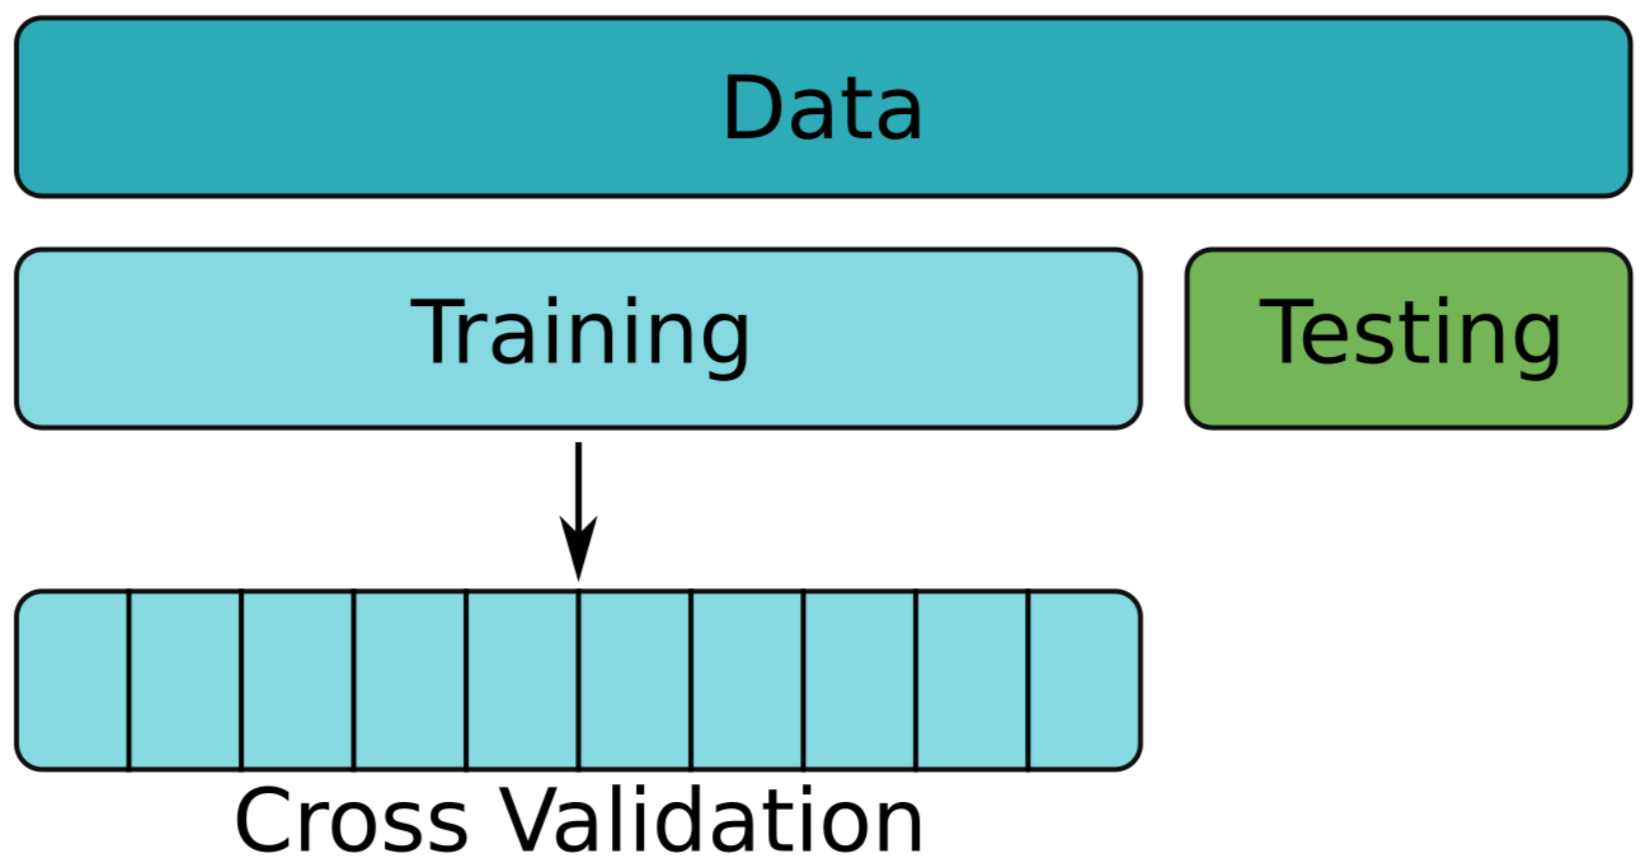

## **5-Fold Cross Validation**

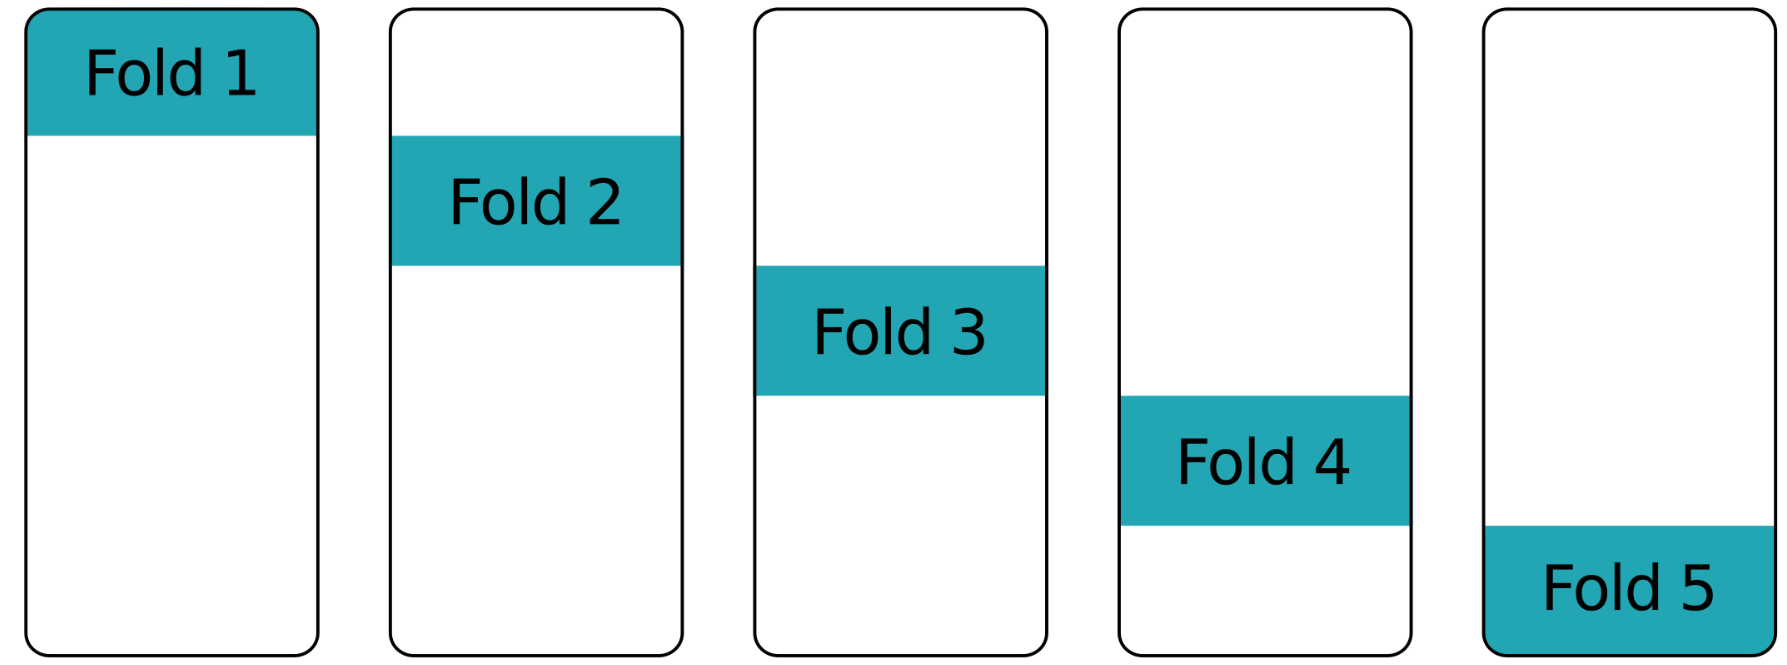

In [ ]:
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.feature import StringIndexer, VectorAssembler, OneHotEncoder, Bucketizer

# Data Preparation
flights = spark.read.csv("flights.csv", header=True, inferSchema=True, nullValue="NA")
flights = flights.withColumn("km", flights["mile"]*1.609344).drop("mile")
indexer = StringIndexer(inputCol="org", outputCol="org_index")
onehot = OneHotEncoder(inputCols=["org_index"], outputCols=["org_dummy"])
assemble = VectorAssembler(inputCols=["km", "org_dummy"], outputCol="features")
flights_train, flights_test = flights.randomSplit([0.8, 0.2], seed=42)
regression = LinearRegression(labelCol="duration")

# Pipeline
pipeline = Pipeline(stages=[indexer, onehot, assemble, regression])
# pipeline = pipeline.fit(flights_train)  ถ้าจะใช้ pipeline กับ cross validation
# predictions = pipeline.transform(flights_test) ยังไม่ต้องทำตรงนี้
evaluator = RegressionEvaluator(labelCol='duration')

## **Grid and Cross-Validator**

In [ ]:
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

# A grid of parameter values (empty for the moment)
params = ParamGridBuilder().build()

# The Cross-Validation object
cv = CrossValidator(estimator=pipeline, # ตรงนี้ ถ้าไม่ได้ใช้ Pipeline ต้องใช้ regression
                    estimatorParamMaps=params,
                    evaluator=evaluator,
                    numFolds=10, seed=13)

## **Train Cross-Validator**

In [ ]:
cv = cv.fit(flights_train)

# Average RMSE across all folds
print(f'An average RMSE is {cv.avgMetrics[0]:.2f}.')

An average RMSE is 11.25.


## **ใช้ cv ซึ่งเป็นสิ่งที่ดีที่สุดในการ estimate**

In [ ]:
predictions = cv.transform(flights_test)

# ไม่ใช่ pipeline.transform(flights_test)

print(f'Best RMSE is {RegressionEvaluator(labelCol='duration').evaluate(predictions):.2f}.')

Best RMSE is 11.07.


# **Grid Search**'

By default a linear regression model will always fit an intercept, but we will be explicit here and specify the **`fitIntercept=True`**

In [ ]:
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.feature import StringIndexer, VectorAssembler, OneHotEncoder, Bucketizer
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

# Data Preparation
flights = spark.read.csv("flights.csv", header=True, inferSchema=True, nullValue="NA")
flights = flights.withColumn("km", flights["mile"]*1.609344).drop("mile")
indexer = StringIndexer(inputCol="org", outputCol="org_index")
onehot = OneHotEncoder(inputCols=["org_index"], outputCols=["org_dummy"])
assemble = VectorAssembler(inputCols=["km", "org_dummy"], outputCol="features")
flights_train, flights_test = flights.randomSplit([0.8, 0.2], seed=42)
regression = LinearRegression(labelCol="duration", fitIntercept=True)

# Pipeline
pipeline = Pipeline(stages=[indexer, onehot, assemble, regression])
pipeline = pipeline.fit(flights_train)
predictions = pipeline.transform(flights_test)
evaluator = RegressionEvaluator(labelCol='duration')
print(f'RMSE for model with an intercept is {evaluator.evaluate(predictions):.2f}')


RMSE for model with an intercept is 11.07


## **Linear Regression without intercept**

In [ ]:
regression = LinearRegression(labelCol='duration', fitIntercept=False)
pipeline = Pipeline(stages=[indexer, onehot, assemble, regression])
pipeline = pipeline.fit(flights_train)
predictions = pipeline.transform(flights_test)
evaluator = RegressionEvaluator(labelCol='duration')
print(f'RMSE for model WITHOUT an intercept is {evaluator.evaluate(predictions):.2f}')

RMSE for model WITHOUT an intercept is 11.28


Generally we choose the model with lower RMSE.  However, just getting a single estimate of RMSE is not robust so we should use cross validation.

## **Parameter Grid**

In [ ]:
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.feature import StringIndexer, VectorAssembler, OneHotEncoder, Bucketizer

# Data Preparation
flights = spark.read.csv("flights.csv", header=True, inferSchema=True, nullValue="NA")
flights = flights.withColumn("km", flights["mile"]*1.609344).drop("mile")
indexer = StringIndexer(inputCol="org", outputCol="org_index")
onehot = OneHotEncoder(inputCols=["org_index"], outputCols=["org_dummy"])
assemble = VectorAssembler(inputCols=["km", "org_dummy"], outputCol="features")
flights_train, flights_test = flights.randomSplit([0.8, 0.2], seed=42)
regression = LinearRegression(labelCol="duration")

# Pipeline
pipeline = Pipeline(stages=[indexer, onehot, assemble, regression])
evaluator = RegressionEvaluator(labelCol='duration')

In [ ]:
from pyspark.ml.tuning import ParamGridBuilder

params = ParamGridBuilder()

# Adding grid points
params = params.addGrid(regression.fitIntercept, [True, False]).build()

print(f'Number of models to be tested =  {len(params)}')

Number of models to be tested =  2


## **Grid Search with Cross-Validation**

In [ ]:
cv = CrossValidator(estimator=pipeline,
                    estimatorParamMaps=params,
                    evaluator=evaluator,
                    numFolds=5, seed=13)
cv = cv.fit(flights_train)
print(f'Average RMSEs for two models are {cv.avgMetrics}.')


Average RMSEs for two models are [np.float64(11.258679810864503), np.float64(11.47210099215749)].


## **The best model and parameters**

In [ ]:
print(cv.bestModel)

# ไม่ต้องมี .stages[-1] ถ้าไม่ได้ใช้ pipeline
print(cv.bestModel.stages[-1].explainParam('fitIntercept'))
print(cv.bestModel.stages[-1].extractParamMap())

# Use the best model to predict
predictions = cv.transform(flights_test)

print(f'Best RMSE is {evaluator.evaluate(predictions):.2f}.')

PipelineModel_bd3ff7a12100
fitIntercept: whether to fit an intercept term. (default: True, current: True)
{Param(parent='LinearRegression_645787aa00da', name='aggregationDepth', doc='suggested depth for treeAggregate (>= 2).'): 2, Param(parent='LinearRegression_645787aa00da', name='elasticNetParam', doc='the ElasticNet mixing parameter, in range [0, 1]. For alpha = 0, the penalty is an L2 penalty. For alpha = 1, it is an L1 penalty.'): 0.0, Param(parent='LinearRegression_645787aa00da', name='epsilon', doc='The shape parameter to control the amount of robustness. Must be > 1.0. Only valid when loss is huber'): 1.35, Param(parent='LinearRegression_645787aa00da', name='featuresCol', doc='features column name.'): 'features', Param(parent='LinearRegression_645787aa00da', name='fitIntercept', doc='whether to fit an intercept term.'): True, Param(parent='LinearRegression_645787aa00da', name='labelCol', doc='label column name.'): 'duration', Param(parent='LinearRegression_645787aa00da', name='

## **Adding even more grid points**

In [ ]:
params = ParamGridBuilder().addGrid(regression.fitIntercept, [True, False]) \
                           .addGrid(regression.regParam, [0.001, 0.01, 0.1, 1, 10]) \
                           .addGrid(regression.elasticNetParam, [0, 0.25, 0.5, 0.75, 1]) \
                           .build()

print(f'Number of models to be tested =  {len(params)}')

Number of models to be tested =  50


### ***Exercise: SMS spam optimised***

The pipeline you built earlier for the SMS spam model used the default parameters for all of the elements in the pipeline. It's very unlikely that these parameters will give a particularly good model though. In this exercise you're going to run the pipeline for a selection of parameter values. We're going to do this in a systematic way: the values for each of the hyperparameters will be laid out on a grid and then pipeline will systematically run across each point in the grid.

In this exercise you'll set up a parameter grid which can be used with cross validation to choose a good set of parameters for the SMS spam classifier.

The following are already defined:

- `hasher` — a HashingTF object and
- `logistic` — a LogisticRegression object.

#### ***Instructions***

- Create a parameter grid builder object.
- Add grid points for numFeatures and binary parameters to the HashingTF object, giving values 1024, 4096 and 16384, and True and False, respectively.
Add grid points for regParam and elasticNetParam parameters to the LogisticRegression object, giving values of 0.01, 0.1, 1.0 and 10.0, and 0.0, 0.5, and 1.0 respectively.
Build the parameter grid.


In [ ]:
from pyspark.ml.feature import Tokenizer, StopWordsRemover, HashingTF, IDF

# Data Preparation
tokenizer = Tokenizer(inputCol='text', outputCol='words')
remover = StopWordsRemover(inputCol="words", outputCol='terms')
hasher = HashingTF(inputCol="terms", outputCol="hash")
idf = IDF(inputCol="hash", outputCol="features")
logistic = LogisticRegression()
pipeline = Pipeline(stages=[tokenizer, remover, hasher, idf, logistic])

schema = StructType([StructField("id", IntegerType()),
                     StructField("text", StringType()),
                     StructField("label", IntegerType())])
REGEX = '[_():;,.!?\\- 0-9]'
sms = spark.read.csv('sms.csv', sep=';', header=False, schema=schema)
sms = sms.withColumn('text', regexp_replace(sms['text'], REGEX, ' '))
sms = sms.withColumn('text', regexp_replace(sms['text'], REGEX, ' '))
sms = sms.withColumn('text', regexp_replace(sms['text'], r" {2,}", ' '))
sms_train, sms_test = sms.randomSplit([0.8, 0.2], seed=13)

In [ ]:
# Create parameter grid
params = ParamGridBuilder()

# Add grid for hashing trick parameters
params = params.addGrid(hasher.numFeatures, [1024, 4096, 16384]) \
               .addGrid(hasher.binary, [True, False])

# Add grid for logistic regression parameters
params = params.addGrid(logistic.regParam, [0.01, 0.1, 1.0, 10.0]) \
               .addGrid(logistic.elasticNetParam, [0.0, 0.5, 1.0])

# Build parameter grid
params = params.build()

### ***Supplementary Exercise: Apply Grid Search Cross Validation to SMS data***

In [ ]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator

evaluator = BinaryClassificationEvaluator(labelCol="label",
                                          metricName="areaUnderROC")
cv = CrossValidator(estimator=pipeline,
                    estimatorParamMaps=params,
                    evaluator=evaluator,
                    numFolds=5,
                    seed=13)

cv = cv.fit(sms_train)
predictions = cv.transform(sms_test)
predictions.groupBy("label", "prediction").count().show()

TP = predictions.where("label = 1 AND prediction = 1").count()
TN = predictions.where("label = 0 AND prediction = 0").count()
FP = predictions.where("label = 0 AND prediction = 1").count()
FN = predictions.where("label = 1 AND prediction = 0").count()
print(f"The accuracy is {(TP+TN)/(TP+TN+FP+FN)*100:.2f}%")

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    1|       0.0|   35|
|    0|       0.0|  950|
|    1|       1.0|  111|
+-----+----------+-----+

The accuracy is 96.81%


In [ ]:
predictions.groupBy("label", "prediction").count().show()

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    1|       0.0|   35|
|    0|       0.0|  950|
|    1|       1.0|  111|
+-----+----------+-----+



โมเดลไม่ได้ทำนายตัวอย่าง Negative ว่าเป็น Positive เลยแม้แต่ตัวเดียว

# **Ensemble**

An ensemble model combines the result from multiple models to produce better predictions.

## **Random Forest**

In [ ]:
from pyspark.ml import Pipeline

# Data Preparation
flights = spark.read.csv("flights.csv", header=True, inferSchema=True, nullValue="NA")
flights = flights.dropna()
flights = flights.withColumn("km", flights["mile"]*1.609344).drop("mile")
flights = flights.withColumn("label", (flights['delay']>=15).cast('integer'))
flights_train, flights_test = flights.randomSplit([0.8, 0.2], seed=42)

# Processes
indexer = StringIndexer(inputCol="org", outputCol="org_index")
onehot = OneHotEncoder(inputCols=["org_index"], outputCols=["org_dummy"])
assemble = VectorAssembler(inputCols=["km", "org_dummy", "duration"], outputCol="features")


In [ ]:
from pyspark.ml.classification import RandomForestClassifier

forest = RandomForestClassifier(numTrees=5)

# Pipeline
pipeline = Pipeline(stages=[indexer, onehot, assemble, forest])
pipeline = pipeline.fit(flights_train)
pipeline.stages[-1].trees

[DecisionTreeClassificationModel: uid=dtc_c10f55e48e65, depth=4, numNodes=15, numClasses=2, numFeatures=9,
 DecisionTreeClassificationModel: uid=dtc_6eb1f9407e09, depth=5, numNodes=19, numClasses=2, numFeatures=9,
 DecisionTreeClassificationModel: uid=dtc_1d997308234a, depth=5, numNodes=17, numClasses=2, numFeatures=9,
 DecisionTreeClassificationModel: uid=dtc_515fc5d6dbca, depth=5, numNodes=13, numClasses=2, numFeatures=9,
 DecisionTreeClassificationModel: uid=dtc_2f57d72b320a, depth=5, numNodes=13, numClasses=2, numFeatures=9]

In [ ]:
predictions = pipeline.transform(flights_test)
predictions['label', 'probability', 'prediction'].show(5, truncate=False)

+-----+---------------------------------------+----------+
|label|probability                            |prediction|
+-----+---------------------------------------+----------+
|1    |[0.427763560345241,0.572236439654759]  |1.0       |
|1    |[0.4517902201045061,0.5482097798954939]|1.0       |
|0    |[0.4313215666051802,0.5686784333948197]|1.0       |
|0    |[0.4395226552580561,0.5604773447419439]|1.0       |
|1    |[0.4313215666051802,0.5686784333948197]|1.0       |
+-----+---------------------------------------+----------+
only showing top 5 rows


## **Feature Importances**

In [ ]:
pipeline.stages[-1].featureImportances

SparseVector(9, {0: 0.1627, 1: 0.164, 2: 0.0249, 4: 0.0115, 5: 0.2125, 6: 0.1503, 7: 0.0707, 8: 0.2034})

สัมประสิทธิ์ เรียงตามลำดับของ **`VectorAssembler`**

## **Gradient-Boosted Trees**

In [ ]:
from pyspark.ml.classification import GBTClassifier

gbt = GBTClassifier(maxIter=10)
pipeline = Pipeline(stages=[indexer, onehot, assemble, gbt])
pipeline = pipeline.fit(flights_train)
predictions_gbt = pipeline.transform(flights_test)

In [ ]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator

evaluator = BinaryClassificationEvaluator(labelCol="label",
                                          metricName="areaUnderROC")
auc = evaluator.evaluate(predictions)
print(f"AUC of Random Forest = {auc:.4f}")

auc = evaluator.evaluate(predictions_gbt)
print(f"AUC of Gradient Boosted Trees = {auc:.4f}")

AUC of Random Forest = 0.5950
AUC of Gradient Boosted Trees = 0.6085


### ***Exercise: Delayed flights with a Random Forest***

In this exercise you'll bring together cross validation and ensemble methods. You'll be training a Random Forest classifier to predict delayed flights, using cross validation to choose the best values for model parameters.

You'll find good values for the following parameters:

- **`featureSubsetStrategy`** — the number of features to consider for splitting at each node and
- **`maxDepth`** — the maximum number of splits along any branch.
Unfortunately building this model takes too long, so we won't be running the **`.fit()`** method on the pipeline.

The **`RandomForestClassifier`** class has already been imported into the session.

##### ***Instructions***

- Create a random forest classifier object.
- Create a parameter grid builder object. Add grid points for the `featureSubsetStrategy` and `maxDepth` parameters.
- Create binary classification evaluator.
- Create a cross-validator object, specifying the estimator, parameter grid and evaluator. Choose 5-fold cross validation.


In [22]:
# Create a random forest classifier
forest = RandomForestClassifier()

# Create a parameter grid
params = ParamGridBuilder() \
            .addGrid(forest.featureSubsetStrategy, ['all', 'onethird', 'sqrt', 'log2']) \
            .addGrid(forest.maxDepth, [2, 5, 10]) \
            .build()

# Create a binary classification evaluator
evaluator = BinaryClassificationEvaluator()

# Create a cross-validator
cv = CrossValidator(estimator=forest, estimatorParamMaps=params, evaluator=evaluator, numFolds=5)

#### ***Supplementary Exercise: Run Cross Validation on Flights Data***

In [23]:
# Prepare data to be like that on Data Camp

flights = spark.read.csv("flights.csv", header=True, inferSchema=True, nullValue="NA")
flights = flights.dropna()
flights = flights.withColumn("label", (flights['delay']>=15).cast('integer'))
flights = VectorAssembler(inputCols=["mon", "depart", "duration"], outputCol="features").transform(flights)
flights = flights.select('mon', 'depart', 'duration', 'features', 'label')
flights_train, flights_test = flights.randomSplit([0.8, 0.2], seed=42)

cv = cv.fit(flights_train)

### ***Exercise: Evaluating Random Forest***

In this final exercise you'll be evaluating the results of cross-validation on a Random Forest model.

The following have already been created:

- `cv` - a cross-validator which has already been fit to the training data
- `evaluator` — a **`BinaryClassificationEvaluator`** object and
- `flights_test` — the testing data.

##### ***Instructions***

- Print a list of average AUC metrics across all models in the parameter grid.
- Display the average AUC for the best model. This will be the largest AUC in the list.
- Print an explanation of the `maxDepth` and `featureSubsetStrategy` parameters for the best model.
- Display the AUC for the best model predictions on the testing data.

In [24]:
# Average AUC for each parameter combination in grid
print(cv.avgMetrics)

# Average AUC for the best model
print(max(cv.avgMetrics))

# What's the optimal parameter value for maxDepth?
print(cv.bestModel.explainParam('maxDepth'))
# What's the optimal parameter value for featureSubsetStrategy?
print(cv.bestModel.explainParam('featureSubsetStrategy'))

# AUC for best model on testing data
print(evaluator.evaluate(cv.transform(flights_test)))

[np.float64(0.6190678946609521), np.float64(0.6583346736266511), np.float64(0.6686195087759097), np.float64(0.6487756953525418), np.float64(0.6616095285770653), np.float64(0.6733524156669878), np.float64(0.6388038722756703), np.float64(0.6619711336504943), np.float64(0.670640292343794), np.float64(0.6388038722756703), np.float64(0.6619711336504943), np.float64(0.670640292343794)]
0.6733524156669878
maxDepth: Maximum depth of the tree. (>= 0) E.g., depth 0 means 1 leaf node; depth 1 means 1 internal node + 2 leaf nodes. Must be in range [0, 30]. (default: 5, current: 10)
featureSubsetStrategy: The number of features to consider for splits at each tree node. Supported options: 'auto' (choose automatically for task: If numTrees == 1, set to 'all'. If numTrees > 1 (forest), set to 'sqrt' for classification and to 'onethird' for regression), 'all' (use all features), 'onethird' (use 1/3 of the features), 'sqrt' (use sqrt(number of features)), 'log2' (use log2(number of features)), 'n' (when

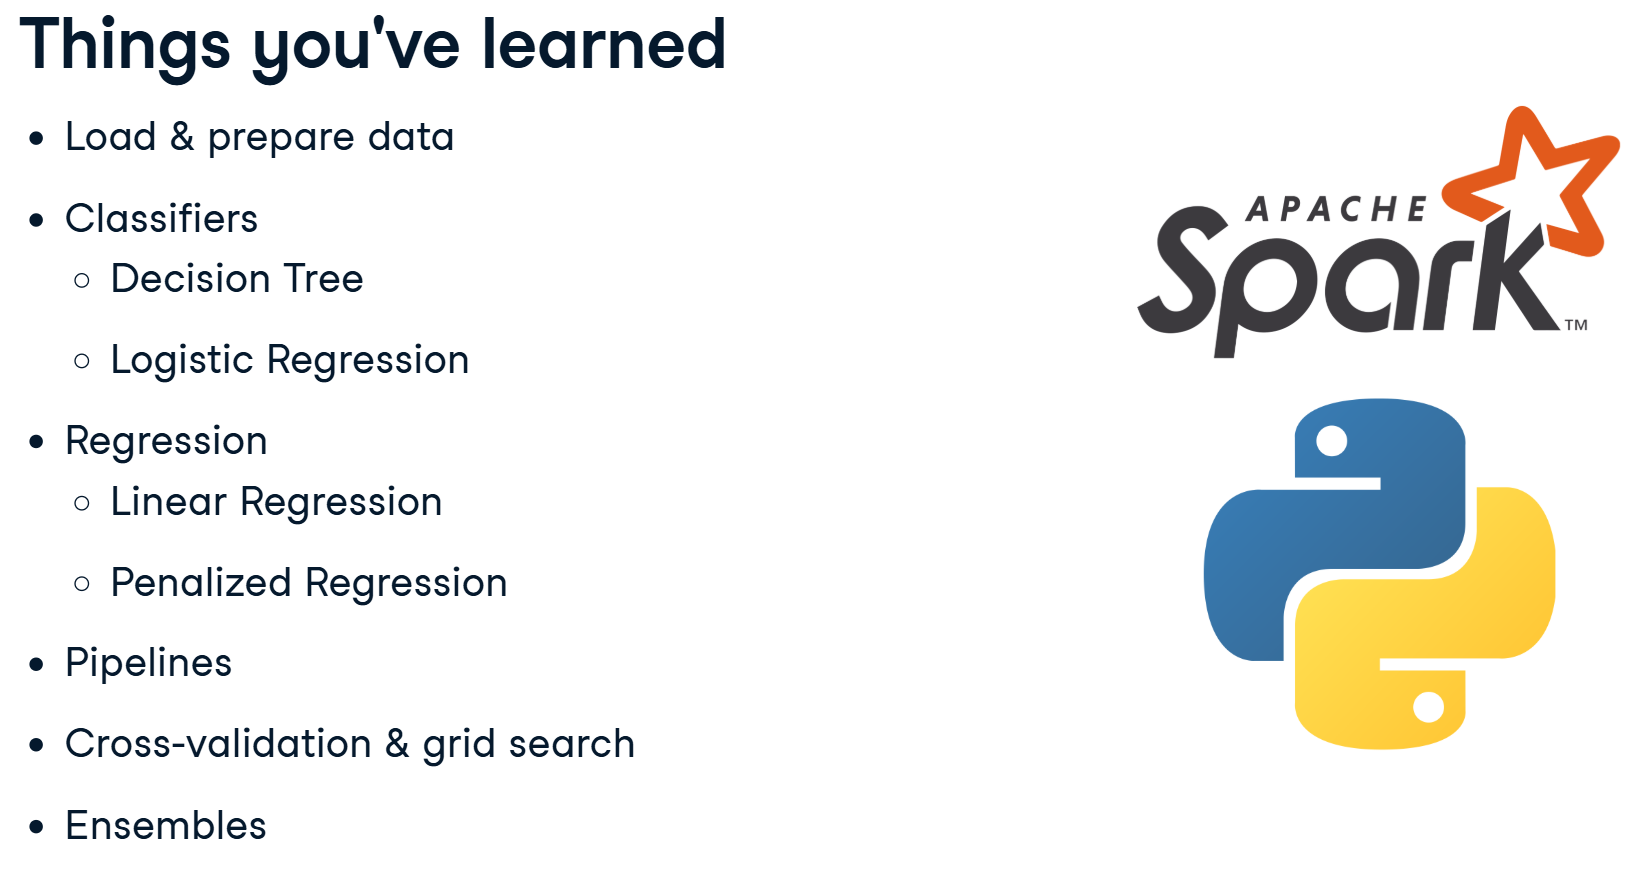